In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahatiratusher/stroke-risk-prediction-dataset/stroke_risk_dataset.csv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 288.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.9 MB/s eta 0:00:00
EXECUTION CONFIGURATION
PyTorch device      : cpu
PennyLane backend   : lightning.qubit
Execution           : CPU optimized quantum simulation

DATASET INFORMATION
Dataset shape: (70000, 18)

First 5 rows:


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1



Missing values:
Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

Target distribution:
At Risk (Binary)
0    24556
1    45444
Name: count, dtype: int64

Target percentage:
At Risk (Binary)
0    35.08
1    64.92
Name: proportion, dtype: float64

Exact duplicate rows: 1021

Number of input features: 16

Input features:
- Chest Pain
- Shortness of Breath
- Irregular Heartbeat
- Fatigue &

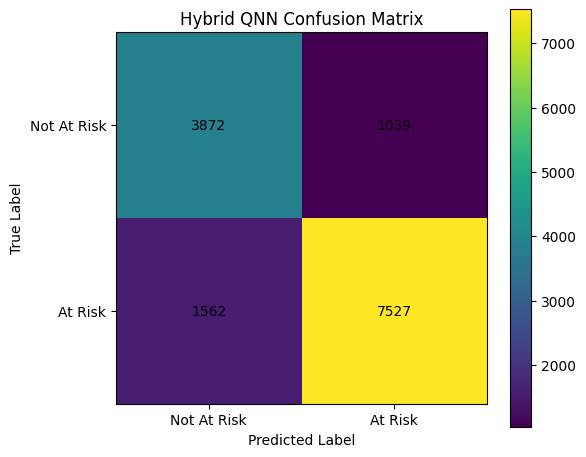

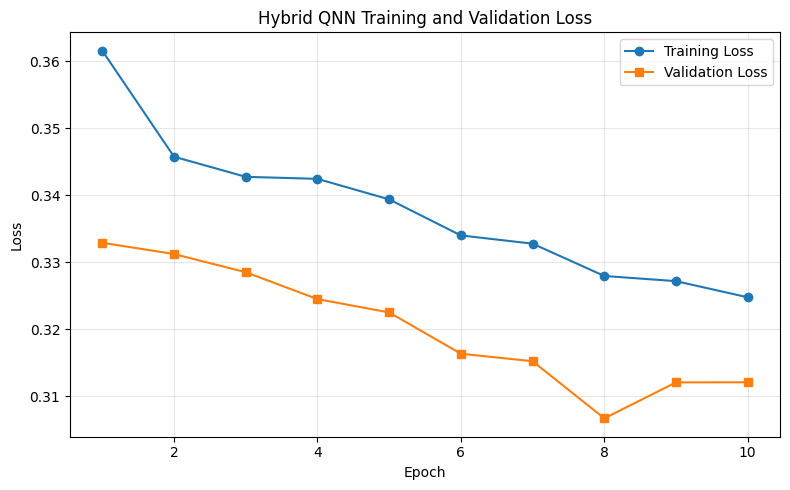

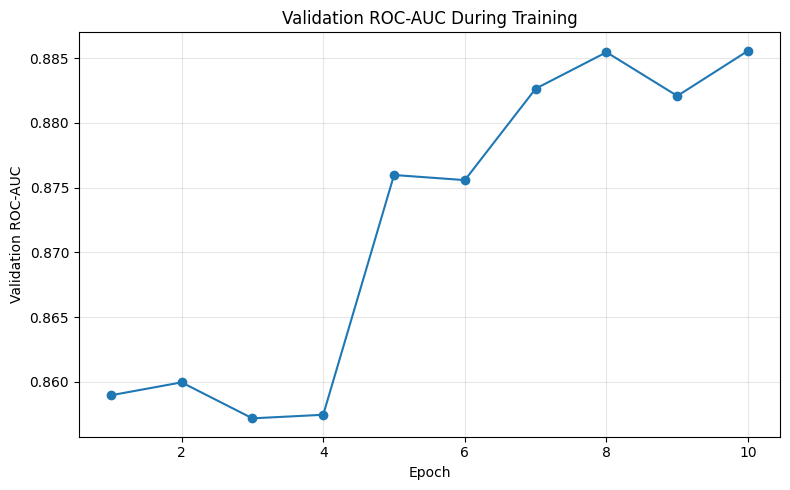

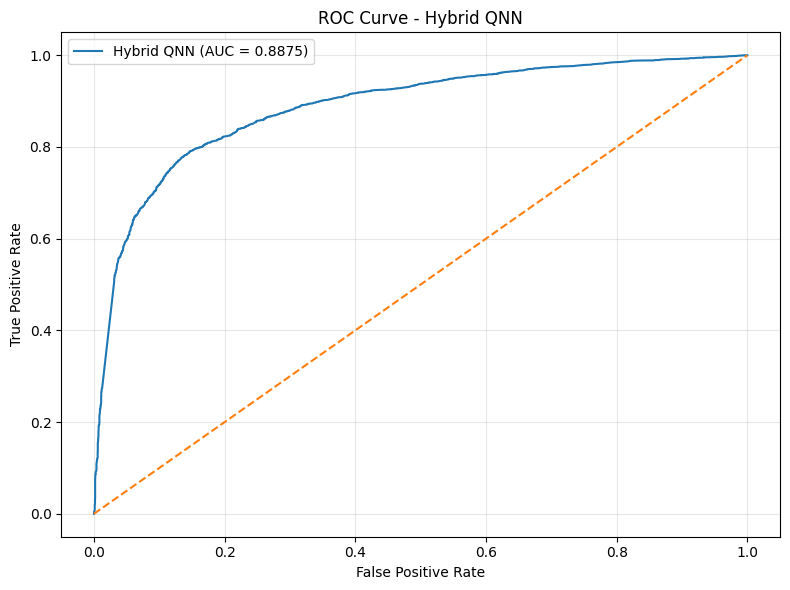

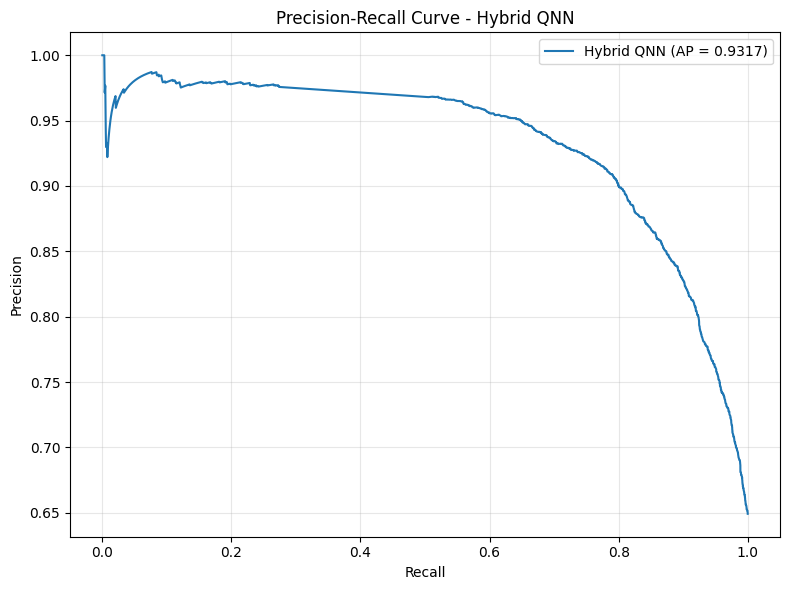

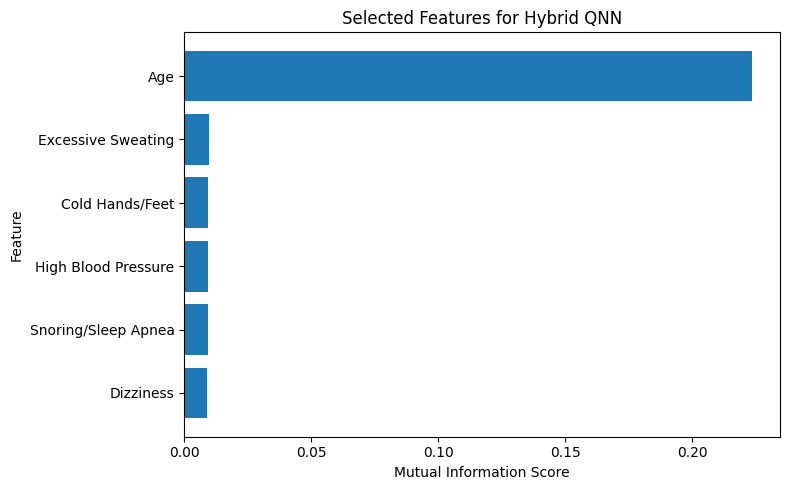


RESULTS TABLE


,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC,Average Precision
0,Hybrid QNN - CPU,0.8142,0.8787,0.8281,0.7884,0.8527,0.8875,0.9317



EXPERIMENT COMPLETED

Model saved at:
/kaggle/working/hybrid_qnn_stroke_cpu.pth

Results saved at:
/kaggle/working/hybrid_qnn_cpu_results.csv

Quantum backend:
lightning.qubit

Execution:
Optimized CPU quantum simulation



In [2]:
# ================================================================
# HYBRID QUANTUM NEURAL NETWORK FOR STROKE RISK PREDICTION
# KAGGLE SINGLE-CELL
# OPTIMIZED CPU VERSION - LIGHTNING.QUBIT
# ================================================================


# ================================================================
# 1. INSTALL PENNYLANE
# ================================================================

!pip install -q pennylane pennylane-lightning


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import random
import warnings
import copy
import time

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ================================================================
# 3. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ================================================================
# 4. DEVICE
# ================================================================

# IMPORTANT:
#
# For this small 6-qubit quantum circuit,
# optimized CPU simulation is used.
#
# lightning.qubit is generally a better practical
# choice here than forcing GPU execution.

device = torch.device("cpu")


print("=" * 75)
print("EXECUTION CONFIGURATION")
print("=" * 75)

print("PyTorch device      :", device)
print("PennyLane backend   : lightning.qubit")
print("Execution           : CPU optimized quantum simulation")


# ================================================================
# 5. LOAD DATASET
# ================================================================

DATA_PATH = (
    "/kaggle/input/datasets/"
    "mahatiratusher/"
    "stroke-risk-prediction-dataset/"
    "stroke_risk_dataset.csv"
)


df = pd.read_csv(
    DATA_PATH
)


print(
    "\n" + "=" * 75
)

print(
    "DATASET INFORMATION"
)

print(
    "=" * 75
)


print(
    "Dataset shape:",
    df.shape
)


print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)


# ================================================================
# 6. BASIC DATA INSPECTION
# ================================================================

TARGET = "At Risk (Binary)"

LEAKAGE_FEATURE = "Stroke Risk (%)"


required_columns = {
    TARGET,
    LEAKAGE_FEATURE,
    "Age"
}


missing_required = (
    required_columns
    .difference(df.columns)
)


if missing_required:

    raise ValueError(
        f"Required columns missing: "
        f"{missing_required}"
    )


print(
    "\nMissing values:"
)

print(
    df.isnull().sum()
)


print(
    "\nTarget distribution:"
)

print(
    df[TARGET]
    .value_counts()
    .sort_index()
)


print(
    "\nTarget percentage:"
)

print(
    df[TARGET]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)


print(
    "\nExact duplicate rows:",
    df.duplicated().sum()
)


# ================================================================
# 7. REMOVE TARGET LEAKAGE
# ================================================================

# IMPORTANT:
#
# Stroke Risk (%) is directly related to
# At Risk (Binary).
#
# Therefore it MUST NOT be used as an input.


X = df.drop(

    columns=[
        TARGET,
        LEAKAGE_FEATURE
    ]

).copy()


y = (

    df[TARGET]
    .astype(int)
    .copy()
)


# ------------------------------------------------
# Validate binary target
# ------------------------------------------------

if not set(
    y.unique()
).issubset(
    {0, 1}
):

    raise ValueError(
        "Target must contain only 0 and 1."
    )


# ------------------------------------------------
# Validate numeric input features
# ------------------------------------------------

non_numeric_features = (

    X
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)


if non_numeric_features:

    raise ValueError(

        "Non-numeric features detected: "
        f"{non_numeric_features}"
    )


print(
    "\nNumber of input features:",
    X.shape[1]
)


print(
    "\nInput features:"
)


for feature in X.columns:

    print(
        "-",
        feature
    )


print(
    "\nRemoved leakage feature:",
    LEAKAGE_FEATURE
)


# ================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

# Final split:
#
# Training   = 70%
# Validation = 10%
# Testing    = 20%


X_train_full, X_test, y_train_full, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=SEED,

        stratify=y
    )
)


# 12.5% of remaining 80%
# = 10% of complete dataset

X_train, X_val, y_train, y_val = (

    train_test_split(

        X_train_full,
        y_train_full,

        test_size=0.125,

        random_state=SEED,

        stratify=y_train_full
    )
)


print(
    "\n" + "=" * 75
)

print(
    "DATA SPLIT"
)

print(
    "=" * 75
)


print(
    "Training samples   :",
    len(X_train)
)

print(
    "Validation samples :",
    len(X_val)
)

print(
    "Testing samples    :",
    len(X_test)
)


print(

    "\nActual split:",

    f"{len(X_train)/len(df)*100:.1f}% Train |",

    f"{len(X_val)/len(df)*100:.1f}% Validation |",

    f"{len(X_test)/len(df)*100:.1f}% Test"
)


# ================================================================
# 9. MUTUAL INFORMATION FEATURE SELECTION
# ================================================================

# IMPORTANT CORRECTION:
#
# Age is continuous.
#
# Remaining features are binary/discrete.
#
# Feature selection is performed ONLY
# using training data.


discrete_mask = np.array(

    [
        column != "Age"

        for column
        in X_train.columns
    ],

    dtype=bool
)


mi_scores = mutual_info_classif(

    X_train,

    y_train,

    discrete_features=discrete_mask,

    random_state=SEED
)


mi_df = pd.DataFrame({

    "Feature":
        X_train.columns,

    "MI_Score":
        mi_scores
})


mi_df = (

    mi_df

    .sort_values(

        by="MI_Score",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ================================================================
# 10. SELECT TOP 6 FEATURES
# ================================================================

# 6 selected features
# =
# 6 quantum qubits


N_FEATURES = 6


selected_features = (

    mi_df

    .head(
        N_FEATURES
    )

    ["Feature"]

    .tolist()
)


print(
    "\n" + "=" * 75
)

print(
    "SELECTED FEATURES"
)

print(
    "=" * 75
)


for i, feature in enumerate(
    selected_features,
    1
):


    score = (

        mi_df.loc[

            mi_df["Feature"]
            ==
            feature,

            "MI_Score"

        ].iloc[0]
    )


    print(

        f"{i}. "
        f"{feature} "
        f"| MI = {score:.6f}"
    )


# ================================================================
# 11. APPLY FEATURE SELECTION
# ================================================================

X_train_selected = (

    X_train[
        selected_features
    ]
    .copy()
)


X_val_selected = (

    X_val[
        selected_features
    ]
    .copy()
)


X_test_selected = (

    X_test[
        selected_features
    ]
    .copy()
)


# ================================================================
# 12. STANDARD SCALING
# ================================================================

# Scaler is fitted ONLY on training data.


scaler = StandardScaler()


X_train_scaled = (

    scaler.fit_transform(
        X_train_selected
    )
)


X_val_scaled = (

    scaler.transform(
        X_val_selected
    )
)


X_test_scaled = (

    scaler.transform(
        X_test_selected
    )
)


# ================================================================
# 13. QUANTUM ANGLE ENCODING PREPROCESSING
# ================================================================

# tanh limits standardized features.
#
# Resulting quantum angles are approximately:
#
# -pi to +pi


X_train_quantum = (

    np.pi

    *

    np.tanh(
        X_train_scaled
    )
)


X_val_quantum = (

    np.pi

    *

    np.tanh(
        X_val_scaled
    )
)


X_test_quantum = (

    np.pi

    *

    np.tanh(
        X_test_scaled
    )
)


# ================================================================
# 14. CONVERT TO PYTORCH TENSORS
# ================================================================

X_train_tensor = torch.tensor(

    X_train_quantum,

    dtype=torch.float32,

    device=device
)


X_val_tensor = torch.tensor(

    X_val_quantum,

    dtype=torch.float32,

    device=device
)


X_test_tensor = torch.tensor(

    X_test_quantum,

    dtype=torch.float32,

    device=device
)


y_train_tensor = torch.tensor(

    y_train.to_numpy(),

    dtype=torch.float32,

    device=device
)


y_val_tensor = torch.tensor(

    y_val.to_numpy(),

    dtype=torch.float32,

    device=device
)


y_test_tensor = torch.tensor(

    y_test.to_numpy(),

    dtype=torch.float32,

    device=device
)


# ================================================================
# 15. DATASETS AND DATALOADERS
# ================================================================

BATCH_SIZE = 32


loader_generator = (

    torch.Generator()

    .manual_seed(
        SEED
    )
)


train_dataset = TensorDataset(

    X_train_tensor,

    y_train_tensor
)


val_dataset = TensorDataset(

    X_val_tensor,

    y_val_tensor
)


test_dataset = TensorDataset(

    X_test_tensor,

    y_test_tensor
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    generator=loader_generator,

    pin_memory=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    pin_memory=False
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    pin_memory=False
)


# ================================================================
# 16. QUANTUM CONFIGURATION
# ================================================================

N_QUBITS = N_FEATURES

N_Q_LAYERS = 2


# lightning.qubit:
#
# Optimized CPU quantum simulator.


quantum_device = qml.device(

    "lightning.qubit",

    wires=N_QUBITS,

    shots=None
)


print(
    "\n" + "=" * 75
)

print(
    "QUANTUM CONFIGURATION"
)

print(
    "=" * 75
)


print(
    "Quantum simulator      : lightning.qubit"
)

print(
    "Number of qubits       :",
    N_QUBITS
)

print(
    "Quantum layers         :",
    N_Q_LAYERS
)

print(
    "Differentiation        : adjoint"
)

print(
    "Execution device       : CPU"
)


# ================================================================
# 17. QUANTUM CIRCUIT
# ================================================================

@qml.qnode(

    quantum_device,

    interface="torch",

    diff_method="adjoint"
)

def quantum_circuit(

    inputs,

    weights
):


    # ------------------------------------------------
    # DATA ENCODING
    # ------------------------------------------------

    for i in range(
        N_QUBITS
    ):


        qml.RY(

            inputs[i],

            wires=i
        )


    # ------------------------------------------------
    # VARIATIONAL QUANTUM LAYERS
    # ------------------------------------------------

    for layer in range(
        N_Q_LAYERS
    ):


        # --------------------------------------------
        # TRAINABLE ROTATIONS
        # --------------------------------------------

        for i in range(
            N_QUBITS
        ):


            qml.RY(

                weights[
                    layer,
                    i,
                    0
                ],

                wires=i
            )


            qml.RZ(

                weights[
                    layer,
                    i,
                    1
                ],

                wires=i
            )


        # --------------------------------------------
        # RING ENTANGLEMENT
        # --------------------------------------------

        for i in range(
            N_QUBITS - 1
        ):


            qml.CNOT(

                wires=[
                    i,
                    i + 1
                ]
            )


        # Last qubit -> first qubit

        qml.CNOT(

            wires=[
                N_QUBITS - 1,
                0
            ]
        )


    # ------------------------------------------------
    # MEASURE ALL QUBITS
    # ------------------------------------------------

    return tuple(

        qml.expval(
            qml.PauliZ(i)
        )

        for i in range(
            N_QUBITS
        )
    )


# ================================================================
# 18. HYBRID QUANTUM NEURAL NETWORK
# ================================================================

class HybridQNN(
    nn.Module
):


    def __init__(
        self,
        n_qubits,
        n_layers
    ):


        super().__init__()


        self.n_qubits = (
            n_qubits
        )


        self.n_layers = (
            n_layers
        )


        # --------------------------------------------
        # TRAINABLE QUANTUM PARAMETERS
        # --------------------------------------------

        self.q_weights = nn.Parameter(

            0.01

            *

            torch.randn(

                n_layers,

                n_qubits,

                2,

                dtype=torch.float32
            )
        )


        # --------------------------------------------
        # CLASSICAL CLASSIFIER
        # --------------------------------------------

        self.classifier = nn.Sequential(


            nn.Linear(
                n_qubits,
                8
            ),


            nn.ReLU(),


            nn.Dropout(
                0.20
            ),


            nn.Linear(
                8,
                1
            )
        )


    # ------------------------------------------------
    # FORWARD PASS
    # ------------------------------------------------

    def forward(
        self,
        x
    ):


        quantum_outputs = []


        # Each sample passes through
        # the quantum circuit.

        for sample in x:


            q_result = quantum_circuit(

                sample,

                self.q_weights
            )


            q_result = torch.stack(

                list(
                    q_result
                )
            )


            q_result = q_result.to(
                dtype=torch.float32
            )


            quantum_outputs.append(
                q_result
            )


        q_out = torch.stack(

            quantum_outputs,

            dim=0
        )


        logits = self.classifier(
            q_out
        )


        return logits.squeeze(
            1
        )


# ================================================================
# 19. INITIALIZE MODEL
# ================================================================

model = HybridQNN(

    n_qubits=N_QUBITS,

    n_layers=N_Q_LAYERS

).to(
    device
)


print(
    "\n" + "=" * 75
)

print(
    "HYBRID QNN MODEL"
)

print(
    "=" * 75
)


print(
    model
)


print(
    "\nModel device:",
    next(
        model.parameters()
    ).device
)


# ================================================================
# 20. CLASS IMBALANCE
# ================================================================

class_counts = np.bincount(

    y_train.to_numpy(),

    minlength=2
)


negative_count = int(
    class_counts[0]
)


positive_count = int(
    class_counts[1]
)


if (
    negative_count == 0
    or
    positive_count == 0
):

    raise ValueError(
        "Both classes must exist "
        "in training data."
    )


pos_weight = (

    negative_count

    /

    positive_count
)


pos_weight_tensor = torch.tensor(

    pos_weight,

    dtype=torch.float32,

    device=device
)


criterion = nn.BCEWithLogitsLoss(

    pos_weight=pos_weight_tensor
)


print(
    "\nClass 0:",
    negative_count
)


print(
    "Class 1:",
    positive_count
)


print(
    "Positive class weight:",
    round(
        pos_weight,
        6
    )
)


# ================================================================
# 21. OPTIMIZER
# ================================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.01,

    weight_decay=1e-4
)


# ================================================================
# 22. LEARNING RATE SCHEDULER
# ================================================================

scheduler = (

    torch.optim

    .lr_scheduler

    .ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=2
    )
)


# ================================================================
# 23. TRAINING FUNCTION
# ================================================================

def train_one_epoch(

    model,

    loader,

    criterion,

    optimizer
):


    model.train()


    running_loss = 0.0


    for (
        X_batch,
        y_batch
    ) in loader:


        optimizer.zero_grad(
            set_to_none=True
        )


        # --------------------------------------------
        # FORWARD PASS
        # --------------------------------------------

        logits = model(
            X_batch
        )


        # --------------------------------------------
        # LOSS
        # --------------------------------------------

        loss = criterion(

            logits,

            y_batch
        )


        # --------------------------------------------
        # BACKPROPAGATION
        # --------------------------------------------

        loss.backward()


        # --------------------------------------------
        # UPDATE PARAMETERS
        # --------------------------------------------

        optimizer.step()


        running_loss += (

            loss.item()

            *

            X_batch.size(0)
        )


    epoch_loss = (

        running_loss

        /

        len(
            loader.dataset
        )
    )


    return epoch_loss


# ================================================================
# 24. EVALUATION FUNCTION
# ================================================================

# Validation loss + probabilities
# are calculated in ONE pass.


@torch.no_grad()

def evaluate(

    model,

    loader,

    criterion,

    threshold=0.50
):


    model.eval()


    running_loss = 0.0


    all_probs = []

    all_targets = []


    for (
        X_batch,
        y_batch
    ) in loader:


        logits = model(
            X_batch
        )


        loss = criterion(

            logits,

            y_batch
        )


        probabilities = torch.sigmoid(
            logits
        )


        running_loss += (

            loss.item()

            *

            X_batch.size(0)
        )


        all_probs.extend(

            probabilities

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


        all_targets.extend(

            y_batch

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


    average_loss = (

        running_loss

        /

        len(
            loader.dataset
        )
    )


    all_probs = np.asarray(

        all_probs,

        dtype=np.float64
    )


    all_targets = np.asarray(

        all_targets,

        dtype=np.int64
    )


    predictions = (

        all_probs
        >=
        threshold

    ).astype(
        np.int64
    )


    return (

        average_loss,

        all_targets,

        predictions,

        all_probs
    )


# ================================================================
# 25. TRAINING SETTINGS
# ================================================================

EPOCHS = 10


EARLY_STOPPING_PATIENCE = 4


CLASSIFICATION_THRESHOLD = 0.50


train_losses = []

val_losses = []

val_auc_history = []


best_val_auc = (
    -np.inf
)


best_state = None


best_epoch = 0


epochs_without_improvement = 0


# ================================================================
# 26. START TRAINING
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "STARTING HYBRID QNN TRAINING"
)

print(
    "=" * 75
)


training_start = (
    time.time()
)


for epoch in range(
    EPOCHS
):


    epoch_start = (
        time.time()
    )


    # ------------------------------------------------
    # TRAINING
    # ------------------------------------------------

    train_loss = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer
    )


    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    (
        val_loss,

        y_val_true,

        y_val_pred,

        y_val_prob

    ) = evaluate(

        model,

        val_loader,

        criterion,

        CLASSIFICATION_THRESHOLD
    )


    # ------------------------------------------------
    # VALIDATION ROC-AUC
    # ------------------------------------------------

    val_auc = roc_auc_score(

        y_val_true,

        y_val_prob
    )


    # ------------------------------------------------
    # STORE HISTORY
    # ------------------------------------------------

    train_losses.append(
        train_loss
    )


    val_losses.append(
        val_loss
    )


    val_auc_history.append(
        val_auc
    )


    # ------------------------------------------------
    # LEARNING RATE SCHEDULER
    # ------------------------------------------------

    scheduler.step(
        val_loss
    )


    # ------------------------------------------------
    # SAVE BEST MODEL
    # ------------------------------------------------

    if (

        val_auc

        >

        best_val_auc + 1e-8
    ):


        best_val_auc = (
            val_auc
        )


        best_epoch = (
            epoch + 1
        )


        epochs_without_improvement = 0


        best_state = copy.deepcopy(

            model.state_dict()
        )


    else:


        epochs_without_improvement += 1


    current_lr = (

        optimizer
        .param_groups[0]
        ["lr"]
    )


    epoch_time = (

        time.time()

        -

        epoch_start
    )


    print(

        f"Epoch "
        f"[{epoch + 1}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val AUC: "
        f"{val_auc:.4f} | "

        f"LR: "
        f"{current_lr:.6f} | "

        f"Time: "
        f"{epoch_time:.2f}s"
    )


    # ------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------

    if (

        epochs_without_improvement

        >=

        EARLY_STOPPING_PATIENCE
    ):


        print(

            f"\nEarly stopping "
            f"at epoch "
            f"{epoch + 1}."
        )


        break


total_training_time = (

    time.time()

    -

    training_start
)


# ================================================================
# 27. LOAD BEST MODEL
# ================================================================

if best_state is None:

    raise RuntimeError(
        "No valid model checkpoint "
        "was created."
    )


model.load_state_dict(
    best_state
)


print(
    "\nBest validation model loaded."
)


print(
    "Best epoch:",
    best_epoch
)


print(
    "Best validation AUC:",
    round(
        best_val_auc,
        4
    )
)


# ================================================================
# 28. FINAL TEST EVALUATION
# ================================================================

# Test data is used ONLY here.


(
    test_loss,

    y_true,

    y_pred,

    y_prob

) = evaluate(

    model,

    test_loader,

    criterion,

    CLASSIFICATION_THRESHOLD
)


# ================================================================
# 29. CALCULATE TEST METRICS
# ================================================================

accuracy = accuracy_score(

    y_true,

    y_pred
)


precision = precision_score(

    y_true,

    y_pred,

    zero_division=0
)


recall = recall_score(

    y_true,

    y_pred,

    zero_division=0
)


f1 = f1_score(

    y_true,

    y_pred,

    zero_division=0
)


roc_auc = roc_auc_score(

    y_true,

    y_prob
)


average_precision = (

    average_precision_score(

        y_true,

        y_prob
    )
)


# ================================================================
# 30. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_true,

    y_pred,

    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


specificity = (

    tn

    /

    (tn + fp)

    if (
        tn + fp
    ) > 0

    else 0.0
)


# ================================================================
# 31. PRINT FINAL RESULTS
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "FINAL HYBRID QNN TEST RESULTS"
)

print(
    "=" * 75
)


print(

    f"Test Loss          : "
    f"{test_loss:.4f}"
)


print(

    f"Threshold          : "
    f"{CLASSIFICATION_THRESHOLD:.2f}"
)


print(

    f"Accuracy           : "
    f"{accuracy:.4f}"
)


print(

    f"Precision          : "
    f"{precision:.4f}"
)


print(

    f"Recall/Sensitivity : "
    f"{recall:.4f}"
)


print(

    f"Specificity        : "
    f"{specificity:.4f}"
)


print(

    f"F1 Score           : "
    f"{f1:.4f}"
)


print(

    f"ROC-AUC            : "
    f"{roc_auc:.4f}"
)


print(

    f"Average Precision  : "
    f"{average_precision:.4f}"
)


print(

    f"Training Time      : "
    f"{total_training_time:.2f} seconds"
)


print(
    "=" * 75
)


# ================================================================
# 32. CLASSIFICATION REPORT
# ================================================================

print(
    "\nClassification Report:\n"
)


print(

    classification_report(

        y_true,

        y_pred,

        labels=[0, 1],

        target_names=[

            "Not At Risk",

            "At Risk"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 33. CONFUSION MATRIX PLOT
# ================================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm
)


plt.title(
    "Hybrid QNN Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.xticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


plt.yticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


for i in range(2):

    for j in range(2):


        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"
        )


plt.colorbar()


plt.tight_layout()


plt.show()


# ================================================================
# 34. TRAINING / VALIDATION LOSS
# ================================================================

epoch_axis = range(

    1,

    len(
        train_losses
    ) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epoch_axis,

    train_losses,

    marker="o",

    label="Training Loss"
)


plt.plot(

    epoch_axis,

    val_losses,

    marker="s",

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Hybrid QNN Training and Validation Loss"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ================================================================
# 35. VALIDATION ROC-AUC HISTORY
# ================================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epoch_axis,

    val_auc_history,

    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation ROC-AUC"
)


plt.title(
    "Validation ROC-AUC During Training"
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ================================================================
# 36. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(

    y_true,

    y_prob
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    fpr,

    tpr,

    label=(

        f"Hybrid QNN "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - Hybrid QNN"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ================================================================
# 37. PRECISION-RECALL CURVE
# ================================================================

(
    precision_curve,

    recall_curve,

    _
) = precision_recall_curve(

    y_true,

    y_prob
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=(

        f"Hybrid QNN "
        f"(AP = {average_precision:.4f})"
    )
)


plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve - Hybrid QNN"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ================================================================
# 38. MUTUAL INFORMATION FEATURE PLOT
# ================================================================

top_features = mi_df.head(
    N_FEATURES
)


plt.figure(
    figsize=(8, 5)
)


plt.barh(

    top_features[
        "Feature"
    ][::-1],

    top_features[
        "MI_Score"
    ][::-1]
)


plt.xlabel(
    "Mutual Information Score"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Selected Features for Hybrid QNN"
)


plt.tight_layout()


plt.show()


# ================================================================
# 39. RESULTS TABLE
# ================================================================

results = pd.DataFrame({


    "Model": [

        "Hybrid QNN - CPU"
    ],


    "Accuracy": [

        accuracy
    ],


    "Precision": [

        precision
    ],


    "Recall/Sensitivity": [

        recall
    ],


    "Specificity": [

        specificity
    ],


    "F1-Score": [

        f1
    ],


    "ROC-AUC": [

        roc_auc
    ],


    "Average Precision": [

        average_precision
    ]

})


print(
    "\n" + "=" * 75
)

print(
    "RESULTS TABLE"
)

print(
    "=" * 75
)


display(
    results.round(4)
)


# ================================================================
# 40. SAVE MODEL
# ================================================================

MODEL_PATH = (

    "/kaggle/working/"
    "hybrid_qnn_stroke_cpu.pth"
)


RESULTS_PATH = (

    "/kaggle/working/"
    "hybrid_qnn_cpu_results.csv"
)


checkpoint = {


    "model_state_dict":
        model.state_dict(),


    "selected_features":
        selected_features,


    "mi_scores":

        dict(

            zip(

                mi_df["Feature"],

                mi_df["MI_Score"]
            )
        ),


    "scaler_mean":
        scaler.mean_,


    "scaler_scale":
        scaler.scale_,


    "n_qubits":
        N_QUBITS,


    "n_layers":
        N_Q_LAYERS,


    "batch_size":
        BATCH_SIZE,


    "classification_threshold":
        CLASSIFICATION_THRESHOLD,


    "seed":
        SEED,


    "best_epoch":
        best_epoch,


    "best_validation_auc":
        best_val_auc,


    "test_accuracy":
        accuracy,


    "test_precision":
        precision,


    "test_recall":
        recall,


    "test_specificity":
        specificity,


    "test_f1":
        f1,


    "test_roc_auc":
        roc_auc,


    "test_average_precision":
        average_precision,


    "training_time_seconds":
        total_training_time,


    "quantum_device":
        "lightning.qubit",


    "execution_device":
        "CPU",


    "differentiation":
        "adjoint"
}


torch.save(

    checkpoint,

    MODEL_PATH
)


results.to_csv(

    RESULTS_PATH,

    index=False
)


# ================================================================
# 41. FINAL MESSAGE
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "EXPERIMENT COMPLETED"
)

print(
    "=" * 75
)


print(
    "\nModel saved at:"
)

print(
    MODEL_PATH
)


print(
    "\nResults saved at:"
)

print(
    RESULTS_PATH
)


print(
    "\nQuantum backend:"
)

print(
    "lightning.qubit"
)


print(
    "\nExecution:"
)

print(
    "Optimized CPU quantum simulation"
)


print(
    "\n" + "=" * 75
)

QSVM EXECUTION CONFIGURATION
Quantum backend : lightning.qubit
Execution       : CPU
Model           : QSVM
Kernel          : Quantum Fidelity Kernel

DATASET INFORMATION
Dataset shape: (70000, 18)

First 5 rows:


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1



Missing values:
Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

Target distribution:
At Risk (Binary)
0    24556
1    45444
Name: count, dtype: int64

Target percentage:
At Risk (Binary)
0    35.08
1    64.92
Name: proportion, dtype: float64

Exact duplicate rows: 1021

Number of usable input features: 16
Removed leakage feature: Stroke Risk (%)

FULL DATA SPLIT
Training samples   :

,C,Accuracy,Precision,Recall,F1,ROC-AUC,SVM Fit Time (s)
0,0.1,0.790,0.7895,0.9231,0.8511,0.8486,0.0079
1,1.0,0.810,0.8710,0.8308,0.8504,0.8523,0.0033
2,10.0,0.785,0.8718,0.7846,0.8259,0.8233,0.0038
3,100.0,0.770,0.8750,0.7538,0.8099,0.7760,0.0061



BUILDING FINAL TEST QUANTUM KERNEL

Testing left samples: 500
Testing right samples: 500
Testing unique left vectors: 446
Testing unique right vectors: 450
Required unique quantum kernel evaluations: 200700
Testing kernel: 10% complete | Time: 73.9s
Testing kernel: 20% complete | Time: 147.4s
Testing kernel: 30% complete | Time: 219.2s
Testing kernel: 40% complete | Time: 292.1s
Testing kernel: 50% complete | Time: 363.4s
Testing kernel: 60% complete | Time: 436.1s
Testing kernel: 70% complete | Time: 508.9s
Testing kernel: 80% complete | Time: 579.5s
Testing kernel: 90% complete | Time: 652.0s
Testing kernel: 100% complete | Time: 722.7s
Testing kernel completed in 722.75 seconds.

Testing kernel shape: (500, 500)

FINAL QSVM TEST RESULTS
Best C             : 1.0
Accuracy           : 0.8000
Precision          : 0.8617
Recall/Sensitivity : 0.8246
Specificity        : 0.7543
F1 Score           : 0.8428
ROC-AUC            : 0.8193
Average Precision  : 0.8735

Classification Report:

   

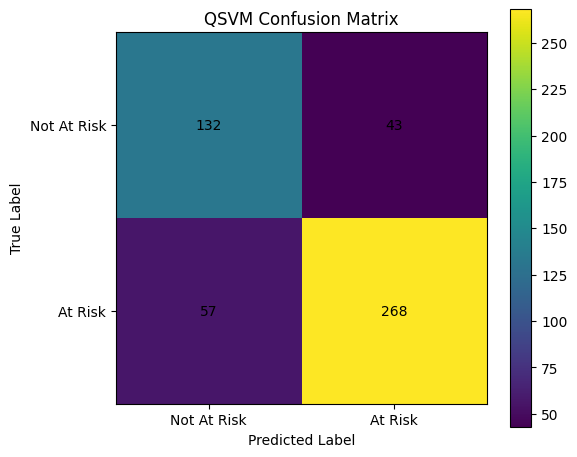

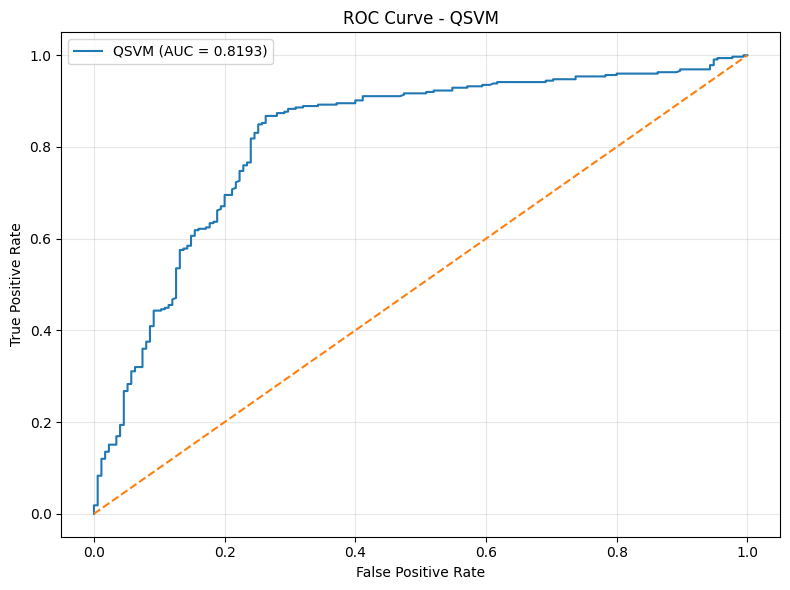

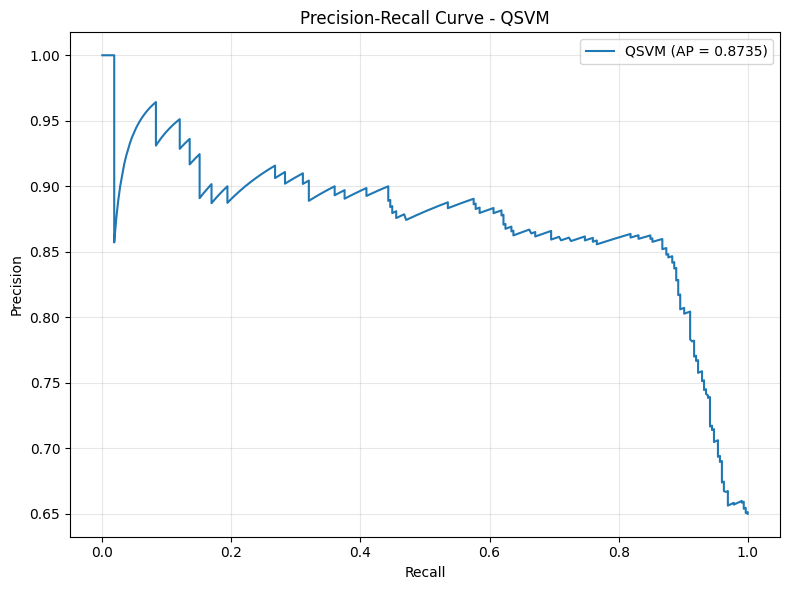

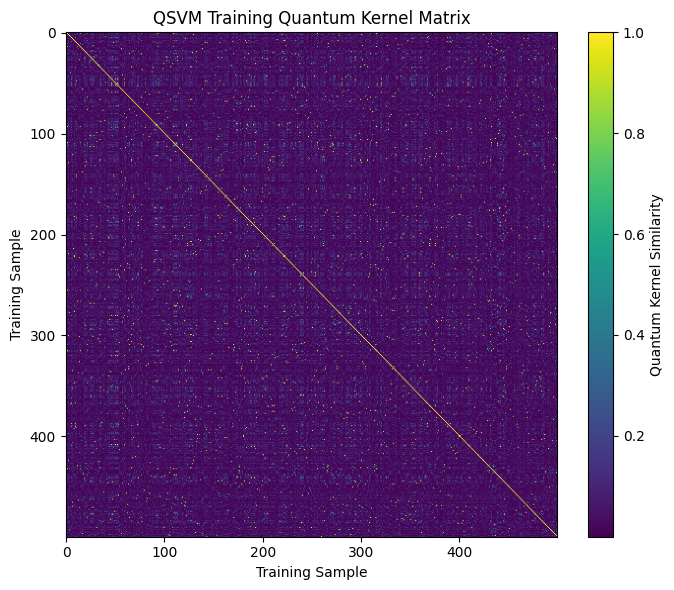

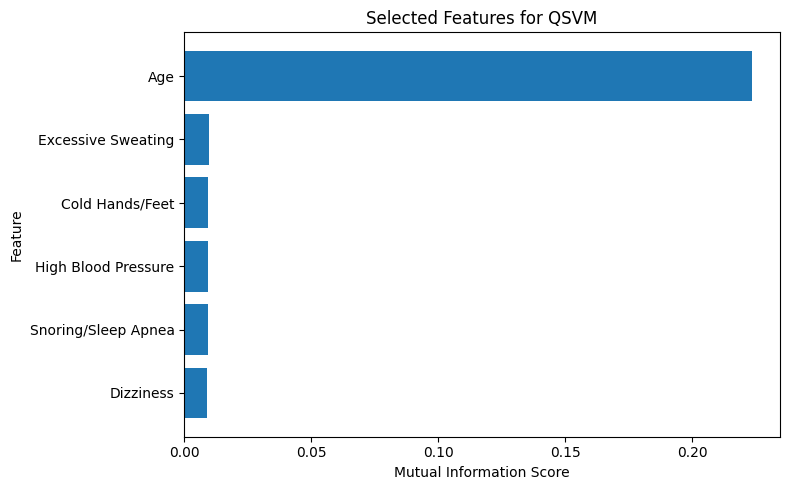


QSVM RESULTS TABLE


,Model,Train Samples,Validation Samples,Test Samples,Qubits,Best C,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC,Average Precision
0,QSVM,500,200,500,6,1.0,0.8,0.8617,0.8246,0.7543,0.8428,0.8193,0.8735



QSVM EXPERIMENT COMPLETED

Model saved at:
/kaggle/working/qsvm_stroke_model.joblib

Final results saved at:
/kaggle/working/qsvm_stroke_results.csv

Validation results saved at:
/kaggle/working/qsvm_validation_results.csv

Quantum backend:
lightning.qubit

Execution:
CPU

Training subset: 500
Validation subset: 200
Testing subset: 500



In [3]:
# ================================================================
# QUANTUM SUPPORT VECTOR MACHINE (QSVM)
# STROKE RISK PREDICTION
# KAGGLE SINGLE-CELL
# CPU + PENNYLANE LIGHTNING.QUBIT
# ================================================================


# ================================================================
# 1. INSTALL PENNYLANE
# ================================================================

!pip install -q pennylane pennylane-lightning


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import random
import warnings
import time
import joblib

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ================================================================
# 3. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ================================================================
# 4. EXECUTION CONFIGURATION
# ================================================================

print("=" * 75)
print("QSVM EXECUTION CONFIGURATION")
print("=" * 75)

print("Quantum backend : lightning.qubit")
print("Execution       : CPU")
print("Model           : QSVM")
print("Kernel          : Quantum Fidelity Kernel")


# ================================================================
# 5. LOAD DATASET
# ================================================================

DATA_PATH = (
    "/kaggle/input/datasets/"
    "mahatiratusher/"
    "stroke-risk-prediction-dataset/"
    "stroke_risk_dataset.csv"
)


df = pd.read_csv(
    DATA_PATH
)


TARGET = "At Risk (Binary)"

LEAKAGE_FEATURE = "Stroke Risk (%)"


print(
    "\n" + "=" * 75
)

print(
    "DATASET INFORMATION"
)

print(
    "=" * 75
)


print(
    "Dataset shape:",
    df.shape
)


print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)


print(
    "\nMissing values:"
)

print(
    df.isnull().sum()
)


print(
    "\nTarget distribution:"
)

print(
    df[TARGET]
    .value_counts()
    .sort_index()
)


print(
    "\nTarget percentage:"
)

print(
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


print(
    "\nExact duplicate rows:",
    df.duplicated().sum()
)


# ================================================================
# 6. VALIDATE DATASET
# ================================================================

required_columns = {
    TARGET,
    LEAKAGE_FEATURE,
    "Age"
}


missing_columns = (
    required_columns
    .difference(df.columns)
)


if missing_columns:

    raise ValueError(
        f"Missing required columns: "
        f"{missing_columns}"
    )


# ================================================================
# 7. REMOVE TARGET LEAKAGE
# ================================================================

# Stroke Risk (%) directly determines
# At Risk (Binary).
#
# Therefore Stroke Risk (%) must NOT
# be used as an input feature.


X = df.drop(

    columns=[
        TARGET,
        LEAKAGE_FEATURE
    ]

).copy()


y = (
    df[TARGET]
    .astype(int)
    .copy()
)


# ------------------------------------------------
# Target validation
# ------------------------------------------------

if not set(
    y.unique()
).issubset({0, 1}):

    raise ValueError(
        "Target must contain only 0 and 1."
    )


# ------------------------------------------------
# Feature validation
# ------------------------------------------------

non_numeric = (

    X
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)


if non_numeric:

    raise ValueError(
        f"Non-numeric features detected: "
        f"{non_numeric}"
    )


print(
    "\nNumber of usable input features:",
    X.shape[1]
)


print(
    "Removed leakage feature:",
    LEAKAGE_FEATURE
)


# ================================================================
# 8. FULL TRAIN / VALIDATION / TEST SPLIT
# ================================================================

# Original dataset:
#
# 70% Training
# 10% Validation
# 20% Testing


X_train_full, X_test, y_train_full, y_test = (
    train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=SEED,

        stratify=y
    )
)


X_train, X_val, y_train, y_val = (
    train_test_split(

        X_train_full,
        y_train_full,

        test_size=0.125,

        random_state=SEED,

        stratify=y_train_full
    )
)


print(
    "\n" + "=" * 75
)

print(
    "FULL DATA SPLIT"
)

print(
    "=" * 75
)


print(
    "Training samples   :",
    len(X_train)
)

print(
    "Validation samples :",
    len(X_val)
)

print(
    "Testing samples    :",
    len(X_test)
)


print(

    "\nSplit:",

    f"{len(X_train)/len(df)*100:.1f}% Train |",

    f"{len(X_val)/len(df)*100:.1f}% Validation |",

    f"{len(X_test)/len(df)*100:.1f}% Test"
)


# ================================================================
# 9. MUTUAL INFORMATION FEATURE SELECTION
# ================================================================

# Age = continuous
#
# Remaining variables = binary/discrete
#
# Feature selection uses ONLY training data.


discrete_mask = np.array(

    [
        column != "Age"

        for column
        in X_train.columns
    ],

    dtype=bool
)


mi_scores = mutual_info_classif(

    X_train,

    y_train,

    discrete_features=discrete_mask,

    random_state=SEED
)


mi_df = pd.DataFrame({

    "Feature":
        X_train.columns,

    "MI_Score":
        mi_scores
})


mi_df = (

    mi_df

    .sort_values(

        by="MI_Score",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ================================================================
# 10. SELECT TOP 6 FEATURES
# ================================================================

# 6 features
# =
# 6 quantum qubits


N_FEATURES = 6


selected_features = (

    mi_df

    .head(
        N_FEATURES
    )

    ["Feature"]

    .tolist()
)


print(
    "\n" + "=" * 75
)

print(
    "SELECTED FEATURES"
)

print(
    "=" * 75
)


for i, feature in enumerate(
    selected_features,
    1
):


    score = (

        mi_df.loc[
            mi_df["Feature"] == feature,
            "MI_Score"
        ]
        .iloc[0]
    )


    print(

        f"{i}. "
        f"{feature} "
        f"| MI = {score:.6f}"
    )


# ================================================================
# 11. APPLY FEATURE SELECTION
# ================================================================

X_train_selected = (
    X_train[
        selected_features
    ]
    .copy()
)


X_val_selected = (
    X_val[
        selected_features
    ]
    .copy()
)


X_test_selected = (
    X_test[
        selected_features
    ]
    .copy()
)


# ================================================================
# 12. STANDARD SCALING
# ================================================================

# Fit scaler ONLY on training data.


scaler = StandardScaler()


X_train_scaled = (
    scaler.fit_transform(
        X_train_selected
    )
)


X_val_scaled = (
    scaler.transform(
        X_val_selected
    )
)


X_test_scaled = (
    scaler.transform(
        X_test_selected
    )
)


# ================================================================
# 13. QUANTUM ANGLE TRANSFORMATION
# ================================================================

# Convert standardized values to
# approximately [-pi, +pi].


X_train_quantum = (
    np.pi
    *
    np.tanh(
        X_train_scaled
    )
)


X_val_quantum = (
    np.pi
    *
    np.tanh(
        X_val_scaled
    )
)


X_test_quantum = (
    np.pi
    *
    np.tanh(
        X_test_scaled
    )
)


# ================================================================
# 14. QSVM SUBSET CONFIGURATION
# ================================================================

# ================================================================
# IMPORTANT
# ================================================================
#
# Full QSVM training with 49,000 samples would require an
# enormous 49,000 x 49,000 quantum kernel matrix.
#
# Therefore QSVM is trained on a stratified subset.
#
# START WITH THESE VALUES.
#
# Later you can increase, for example:
#
# TRAIN = 1000
# VAL   = 300
# TEST  = 1000
#
# ================================================================


QSVM_TRAIN_SIZE = 500

QSVM_VAL_SIZE = 200

QSVM_TEST_SIZE = 500


# ================================================================
# 15. STRATIFIED SUBSET FUNCTION
# ================================================================

def get_stratified_subset(
    X_data,
    y_data,
    subset_size,
    seed
):


    y_array = np.asarray(
        y_data,
        dtype=np.int64
    )


    indices = np.arange(
        len(y_array)
    )


    if subset_size >= len(indices):

        selected_indices = (
            indices
        )


    else:

        selected_indices, _ = (
            train_test_split(

                indices,

                train_size=subset_size,

                random_state=seed,

                stratify=y_array
            )
        )


    return (

        X_data[
            selected_indices
        ],

        y_array[
            selected_indices
        ]
    )


# ================================================================
# 16. CREATE QSVM SUBSETS
# ================================================================

X_qtrain, y_qtrain = (
    get_stratified_subset(

        X_train_quantum,

        y_train,

        QSVM_TRAIN_SIZE,

        SEED
    )
)


X_qval, y_qval = (
    get_stratified_subset(

        X_val_quantum,

        y_val,

        QSVM_VAL_SIZE,

        SEED + 1
    )
)


X_qtest, y_qtest = (
    get_stratified_subset(

        X_test_quantum,

        y_test,

        QSVM_TEST_SIZE,

        SEED + 2
    )
)


print(
    "\n" + "=" * 75
)

print(
    "QSVM SUBSET"
)

print(
    "=" * 75
)


print(
    "QSVM training samples   :",
    len(X_qtrain)
)

print(
    "QSVM validation samples :",
    len(X_qval)
)

print(
    "QSVM testing samples    :",
    len(X_qtest)
)


print(
    "\nQSVM train class distribution:"
)

print(
    pd.Series(
        y_qtrain
    )
    .value_counts()
    .sort_index()
)


# ================================================================
# 17. QUANTUM DEVICE
# ================================================================

N_QUBITS = (
    N_FEATURES
)


FEATURE_MAP_REPS = 2


quantum_device = qml.device(

    "lightning.qubit",

    wires=N_QUBITS,

    shots=None
)


print(
    "\n" + "=" * 75
)

print(
    "QUANTUM CONFIGURATION"
)

print(
    "=" * 75
)


print(
    "Quantum backend    : lightning.qubit"
)

print(
    "Execution device   : CPU"
)

print(
    "Number of qubits   :",
    N_QUBITS
)

print(
    "Feature map repeats:",
    FEATURE_MAP_REPS
)

print(
    "Kernel             : Fidelity kernel"
)


# ================================================================
# 18. QUANTUM FEATURE MAP
# ================================================================

# U(x)
#
# Each classical vector is encoded into
# a 6-qubit quantum state.
#
# No trainable quantum parameters are used.
#
# This is a quantum kernel method,
# not a variational QNN.


def feature_map(
    x
):


    for _ in range(
        FEATURE_MAP_REPS
    ):


        # --------------------------------------------
        # Y-angle encoding
        # --------------------------------------------

        qml.AngleEmbedding(

            x,

            wires=range(
                N_QUBITS
            ),

            rotation="Y"
        )


        # --------------------------------------------
        # Ring entanglement
        # --------------------------------------------

        for i in range(
            N_QUBITS - 1
        ):


            qml.CNOT(

                wires=[
                    i,
                    i + 1
                ]
            )


        qml.CNOT(

            wires=[
                N_QUBITS - 1,
                0
            ]
        )


        # --------------------------------------------
        # Additional feature-dependent Z rotations
        # --------------------------------------------

        qml.AngleEmbedding(

            x,

            wires=range(
                N_QUBITS
            ),

            rotation="Z"
        )


# ================================================================
# 19. QUANTUM FIDELITY KERNEL CIRCUIT
# ================================================================

@qml.qnode(
    quantum_device
)

def kernel_circuit(
    x1,
    x2
):


    # Prepare |psi(x1)>

    feature_map(
        x1
    )


    # Apply U(x2)^dagger

    qml.adjoint(
        feature_map
    )(
        x2
    )


    # Probability of returning to |000000>
    #
    # This corresponds to:
    #
    # |<psi(x2)|psi(x1)>|^2


    return qml.probs(

        wires=range(
            N_QUBITS
        )
    )


# ================================================================
# 20. QUANTUM KERNEL FUNCTION
# ================================================================

def quantum_kernel(
    x1,
    x2
):


    probabilities = kernel_circuit(
        x1,
        x2
    )


    value = float(
        probabilities[0]
    )


    # Numerical protection

    return float(
        np.clip(
            value,
            0.0,
            1.0
        )
    )


# ================================================================
# 21. TEST KERNEL BEFORE FULL COMPUTATION
# ================================================================

self_kernel = quantum_kernel(

    X_qtrain[0],

    X_qtrain[0]
)


cross_kernel = quantum_kernel(

    X_qtrain[0],

    X_qtrain[1]
)


print(
    "\nQuantum kernel test:"
)

print(
    "K(x0, x0) =",
    round(
        self_kernel,
        6
    )
)

print(
    "K(x0, x1) =",
    round(
        cross_kernel,
        6
    )
)


# ================================================================
# 22. UNIQUE FEATURE-VECTOR COMPRESSION
# ================================================================

# Many records may contain exactly the same
# selected feature combination.
#
# Computing their quantum state repeatedly
# would waste time.
#
# Therefore identical encoded vectors are
# calculated once and then expanded back.


def unique_vectors(
    X_data
):


    rounded = np.round(
        X_data,
        decimals=12
    )


    unique_X, inverse = np.unique(

        rounded,

        axis=0,

        return_inverse=True
    )


    return (
        unique_X,
        inverse
    )


# ================================================================
# 23. SQUARE QUANTUM KERNEL MATRIX
# ================================================================

def build_square_kernel_matrix(
    X_data,
    matrix_name="Training"
):


    unique_X, inverse = (
        unique_vectors(
            X_data
        )
    )


    n_unique = len(
        unique_X
    )


    print(
        f"\n{matrix_name} samples:",
        len(X_data)
    )


    print(
        f"{matrix_name} unique quantum vectors:",
        n_unique
    )


    total_evaluations = (

        n_unique
        *
        (
            n_unique + 1
        )
        //
        2
    )


    print(
        "Required unique quantum kernel evaluations:",
        total_evaluations
    )


    K_unique = np.zeros(

        (
            n_unique,
            n_unique
        ),

        dtype=np.float64
    )


    start_time = (
        time.time()
    )


    next_report = 10


    completed = 0


    for i in range(
        n_unique
    ):


        for j in range(
            i,
            n_unique
        ):


            if i == j:

                value = 1.0


            else:

                value = quantum_kernel(

                    unique_X[i],

                    unique_X[j]
                )


            K_unique[
                i,
                j
            ] = value


            K_unique[
                j,
                i
            ] = value


            completed += 1


        percentage = int(

            completed
            /
            total_evaluations
            *
            100
        )


        if percentage >= next_report:

            elapsed = (
                time.time()
                -
                start_time
            )


            print(

                f"{matrix_name} kernel: "
                f"{percentage}% complete "
                f"| Time: "
                f"{elapsed:.1f}s"
            )


            next_report += 10


    # --------------------------------------------
    # Expand unique matrix back to all samples
    # --------------------------------------------

    K = K_unique[
        np.ix_(
            inverse,
            inverse
        )
    ]


    # Numerical cleanup

    K = (
        K
        +
        K.T
    ) / 2.0


    K = np.clip(
        K,
        0.0,
        1.0
    )


    np.fill_diagonal(
        K,
        1.0
    )


    total_time = (
        time.time()
        -
        start_time
    )


    print(

        f"{matrix_name} kernel completed "
        f"in {total_time:.2f} seconds."
    )


    return (
        K,
        total_time
    )


# ================================================================
# 24. CROSS QUANTUM KERNEL MATRIX
# ================================================================

def build_cross_kernel_matrix(

    X_left,

    X_right,

    matrix_name="Cross"

):


    unique_left, inverse_left = (
        unique_vectors(
            X_left
        )
    )


    unique_right, inverse_right = (
        unique_vectors(
            X_right
        )
    )


    n_left = len(
        unique_left
    )


    n_right = len(
        unique_right
    )


    print(
        f"\n{matrix_name} left samples:",
        len(X_left)
    )


    print(
        f"{matrix_name} right samples:",
        len(X_right)
    )


    print(
        f"{matrix_name} unique left vectors:",
        n_left
    )


    print(
        f"{matrix_name} unique right vectors:",
        n_right
    )


    total_evaluations = (

        n_left
        *
        n_right
    )


    print(
        "Required unique quantum kernel evaluations:",
        total_evaluations
    )


    K_unique = np.zeros(

        (
            n_left,
            n_right
        ),

        dtype=np.float64
    )


    start_time = (
        time.time()
    )


    next_report = 10


    completed = 0


    for i in range(
        n_left
    ):


        for j in range(
            n_right
        ):


            K_unique[
                i,
                j
            ] = quantum_kernel(

                unique_left[i],

                unique_right[j]
            )


            completed += 1


        percentage = int(

            completed
            /
            total_evaluations
            *
            100
        )


        if percentage >= next_report:

            elapsed = (
                time.time()
                -
                start_time
            )


            print(

                f"{matrix_name} kernel: "
                f"{percentage}% complete "
                f"| Time: "
                f"{elapsed:.1f}s"
            )


            next_report += 10


    # --------------------------------------------
    # Expand back to original samples
    # --------------------------------------------

    K = K_unique[

        inverse_left[:, None],

        inverse_right[None, :]
    ]


    K = np.clip(
        K,
        0.0,
        1.0
    )


    total_time = (
        time.time()
        -
        start_time
    )


    print(

        f"{matrix_name} kernel completed "
        f"in {total_time:.2f} seconds."
    )


    return (
        K,
        total_time
    )


# ================================================================
# 25. BUILD TRAINING QUANTUM KERNEL
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "BUILDING TRAINING QUANTUM KERNEL"
)

print(
    "=" * 75
)


K_train, train_kernel_time = (
    build_square_kernel_matrix(

        X_qtrain,

        matrix_name="Training"
    )
)


print(
    "\nTraining kernel shape:",
    K_train.shape
)


# ================================================================
# 26. BUILD VALIDATION QUANTUM KERNEL
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "BUILDING VALIDATION QUANTUM KERNEL"
)

print(
    "=" * 75
)


K_val, val_kernel_time = (
    build_cross_kernel_matrix(

        X_qval,

        X_qtrain,

        matrix_name="Validation"
    )
)


print(
    "\nValidation kernel shape:",
    K_val.shape
)


# ================================================================
# 27. SELECT SVM C USING VALIDATION SET
# ================================================================

# No new quantum calculations are required
# when testing different C values.
#
# The same quantum kernel matrices are reused.


C_VALUES = [
    0.1,
    1.0,
    10.0,
    100.0
]


validation_results = []


best_val_auc = (
    -np.inf
)


best_C = None

best_model = None


print(
    "\n" + "=" * 75
)

print(
    "QSVM HYPERPARAMETER SELECTION"
)

print(
    "=" * 75
)


for C in C_VALUES:


    svm = SVC(

        kernel="precomputed",

        C=C,

        class_weight="balanced",

        probability=False,

        random_state=SEED
    )


    fit_start = (
        time.time()
    )


    svm.fit(

        K_train,

        y_qtrain
    )


    fit_time = (
        time.time()
        -
        fit_start
    )


    val_pred = svm.predict(
        K_val
    )


    val_scores = (
        svm.decision_function(
            K_val
        )
    )


    val_accuracy = accuracy_score(

        y_qval,

        val_pred
    )


    val_precision = precision_score(

        y_qval,

        val_pred,

        zero_division=0
    )


    val_recall = recall_score(

        y_qval,

        val_pred,

        zero_division=0
    )


    val_f1 = f1_score(

        y_qval,

        val_pred,

        zero_division=0
    )


    val_auc = roc_auc_score(

        y_qval,

        val_scores
    )


    validation_results.append({

        "C":
            C,

        "Accuracy":
            val_accuracy,

        "Precision":
            val_precision,

        "Recall":
            val_recall,

        "F1":
            val_f1,

        "ROC-AUC":
            val_auc,

        "SVM Fit Time (s)":
            fit_time
    })


    print(

        f"C = {C:<6} | "

        f"Accuracy: "
        f"{val_accuracy:.4f} | "

        f"F1: "
        f"{val_f1:.4f} | "

        f"ROC-AUC: "
        f"{val_auc:.4f}"
    )


    if val_auc > best_val_auc:

        best_val_auc = (
            val_auc
        )

        best_C = (
            C
        )

        best_model = (
            svm
        )


validation_df = pd.DataFrame(
    validation_results
)


print(
    "\nBest C:",
    best_C
)


print(
    "Best validation ROC-AUC:",
    round(
        best_val_auc,
        4
    )
)


print(
    "\nValidation results:"
)

display(
    validation_df.round(4)
)


# ================================================================
# 28. BUILD FINAL TEST QUANTUM KERNEL
# ================================================================

# Test set is touched ONLY after
# hyperparameter selection.


print(
    "\n" + "=" * 75
)

print(
    "BUILDING FINAL TEST QUANTUM KERNEL"
)

print(
    "=" * 75
)


K_test, test_kernel_time = (
    build_cross_kernel_matrix(

        X_qtest,

        X_qtrain,

        matrix_name="Testing"
    )
)


print(
    "\nTesting kernel shape:",
    K_test.shape
)


# ================================================================
# 29. FINAL QSVM PREDICTIONS
# ================================================================

y_pred = best_model.predict(
    K_test
)


y_score = (
    best_model.decision_function(
        K_test
    )
)


# ================================================================
# 30. FINAL TEST METRICS
# ================================================================

accuracy = accuracy_score(

    y_qtest,

    y_pred
)


precision = precision_score(

    y_qtest,

    y_pred,

    zero_division=0
)


recall = recall_score(

    y_qtest,

    y_pred,

    zero_division=0
)


f1 = f1_score(

    y_qtest,

    y_pred,

    zero_division=0
)


roc_auc = roc_auc_score(

    y_qtest,

    y_score
)


average_precision = (
    average_precision_score(

        y_qtest,

        y_score
    )
)


cm = confusion_matrix(

    y_qtest,

    y_pred,

    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


specificity = (

    tn

    /

    (tn + fp)

    if (
        tn + fp
    ) > 0

    else 0.0
)


# ================================================================
# 31. PRINT FINAL TEST RESULTS
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "FINAL QSVM TEST RESULTS"
)

print(
    "=" * 75
)


print(
    f"Best C             : "
    f"{best_C}"
)


print(
    f"Accuracy           : "
    f"{accuracy:.4f}"
)


print(
    f"Precision          : "
    f"{precision:.4f}"
)


print(
    f"Recall/Sensitivity : "
    f"{recall:.4f}"
)


print(
    f"Specificity        : "
    f"{specificity:.4f}"
)


print(
    f"F1 Score           : "
    f"{f1:.4f}"
)


print(
    f"ROC-AUC            : "
    f"{roc_auc:.4f}"
)


print(
    f"Average Precision  : "
    f"{average_precision:.4f}"
)


print(
    "=" * 75
)


# ================================================================
# 32. CLASSIFICATION REPORT
# ================================================================

print(
    "\nClassification Report:\n"
)


print(

    classification_report(

        y_qtest,

        y_pred,

        labels=[0, 1],

        target_names=[

            "Not At Risk",

            "At Risk"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 33. COMPUTATION TIME SUMMARY
# ================================================================

total_kernel_time = (

    train_kernel_time
    +
    val_kernel_time
    +
    test_kernel_time
)


print(
    "\n" + "=" * 75
)

print(
    "QUANTUM KERNEL COMPUTATION TIME"
)

print(
    "=" * 75
)


print(

    f"Training kernel   : "
    f"{train_kernel_time:.2f} sec"
)


print(

    f"Validation kernel : "
    f"{val_kernel_time:.2f} sec"
)


print(

    f"Testing kernel    : "
    f"{test_kernel_time:.2f} sec"
)


print(

    f"Total kernel time : "
    f"{total_kernel_time:.2f} sec"
)


# ================================================================
# 34. CONFUSION MATRIX PLOT
# ================================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm
)


plt.title(
    "QSVM Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.xticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


plt.yticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


for i in range(2):

    for j in range(2):


        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ================================================================
# 35. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(

    y_qtest,

    y_score
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    fpr,

    tpr,

    label=(

        f"QSVM "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - QSVM"
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 36. PRECISION-RECALL CURVE
# ================================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        y_qtest,

        y_score
    )
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=(

        f"QSVM "
        f"(AP = {average_precision:.4f})"
    )
)


plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve - QSVM"
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 37. QUANTUM KERNEL MATRIX VISUALIZATION
# ================================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    K_train,
    aspect="auto"
)


plt.title(
    "QSVM Training Quantum Kernel Matrix"
)


plt.xlabel(
    "Training Sample"
)


plt.ylabel(
    "Training Sample"
)


plt.colorbar(
    label="Quantum Kernel Similarity"
)


plt.tight_layout()

plt.show()


# ================================================================
# 38. MUTUAL INFORMATION FEATURE PLOT
# ================================================================

top_features = mi_df.head(
    N_FEATURES
)


plt.figure(
    figsize=(8, 5)
)


plt.barh(

    top_features[
        "Feature"
    ][::-1],

    top_features[
        "MI_Score"
    ][::-1]
)


plt.xlabel(
    "Mutual Information Score"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Selected Features for QSVM"
)


plt.tight_layout()

plt.show()


# ================================================================
# 39. RESULTS TABLE
# ================================================================

results = pd.DataFrame({


    "Model": [

        "QSVM"
    ],


    "Train Samples": [

        len(X_qtrain)
    ],


    "Validation Samples": [

        len(X_qval)
    ],


    "Test Samples": [

        len(X_qtest)
    ],


    "Qubits": [

        N_QUBITS
    ],


    "Best C": [

        best_C
    ],


    "Accuracy": [

        accuracy
    ],


    "Precision": [

        precision
    ],


    "Recall/Sensitivity": [

        recall
    ],


    "Specificity": [

        specificity
    ],


    "F1-Score": [

        f1
    ],


    "ROC-AUC": [

        roc_auc
    ],


    "Average Precision": [

        average_precision
    ]

})


print(
    "\n" + "=" * 75
)

print(
    "QSVM RESULTS TABLE"
)

print(
    "=" * 75
)


display(
    results.round(4)
)


# ================================================================
# 40. SAVE MODEL + PREPROCESSING INFORMATION
# ================================================================

MODEL_PATH = (

    "/kaggle/working/"
    "qsvm_stroke_model.joblib"
)


RESULTS_PATH = (

    "/kaggle/working/"
    "qsvm_stroke_results.csv"
)


VALIDATION_RESULTS_PATH = (

    "/kaggle/working/"
    "qsvm_validation_results.csv"
)


# ================================================================
# 41. SAVE QSVM PACKAGE
# ================================================================

qsvm_package = {


    "model":
        best_model,


    "selected_features":
        selected_features,


    "scaler":
        scaler,


    "n_qubits":
        N_QUBITS,


    "feature_map_reps":
        FEATURE_MAP_REPS,


    "best_C":
        best_C,


    "seed":
        SEED,


    "qsvm_train_size":
        QSVM_TRAIN_SIZE,


    "qsvm_validation_size":
        QSVM_VAL_SIZE,


    "qsvm_test_size":
        QSVM_TEST_SIZE,


    "training_quantum_vectors":
        X_qtrain,


    "training_labels":
        y_qtrain,


    "test_accuracy":
        accuracy,


    "test_precision":
        precision,


    "test_recall":
        recall,


    "test_specificity":
        specificity,


    "test_f1":
        f1,


    "test_roc_auc":
        roc_auc,


    "test_average_precision":
        average_precision,


    "quantum_backend":
        "lightning.qubit",


    "execution_device":
        "CPU",


    "kernel_type":
        "Quantum Fidelity Kernel"
}


joblib.dump(

    qsvm_package,

    MODEL_PATH
)


results.to_csv(

    RESULTS_PATH,

    index=False
)


validation_df.to_csv(

    VALIDATION_RESULTS_PATH,

    index=False
)


# ================================================================
# 42. FINAL MESSAGE
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "QSVM EXPERIMENT COMPLETED"
)

print(
    "=" * 75
)


print(
    "\nModel saved at:"
)

print(
    MODEL_PATH
)


print(
    "\nFinal results saved at:"
)

print(
    RESULTS_PATH
)


print(
    "\nValidation results saved at:"
)

print(
    VALIDATION_RESULTS_PATH
)


print(
    "\nQuantum backend:"
)

print(
    "lightning.qubit"
)


print(
    "\nExecution:"
)

print(
    "CPU"
)


print(
    "\nTraining subset:",
    QSVM_TRAIN_SIZE
)


print(
    "Validation subset:",
    QSVM_VAL_SIZE
)


print(
    "Testing subset:",
    QSVM_TEST_SIZE
)


print(
    "\n" + "=" * 75
)

QVC EXECUTION CONFIGURATION
PyTorch device      : cpu
Quantum backend     : lightning.qubit
Execution           : CPU
Model               : Quantum Variational Classifier

DATASET INFORMATION
Dataset shape: (70000, 18)

First 5 rows:


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1



Missing values:
Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

Target distribution:
At Risk (Binary)
0    24556
1    45444
Name: count, dtype: int64

Target percentage:
At Risk (Binary)
0    35.08
1    64.92
Name: proportion, dtype: float64

Exact duplicate rows: 1021

Number of usable input features: 16

Input features:
- Chest Pain
- Shortness of Breath
- Irregular Heartbeat
- Fa

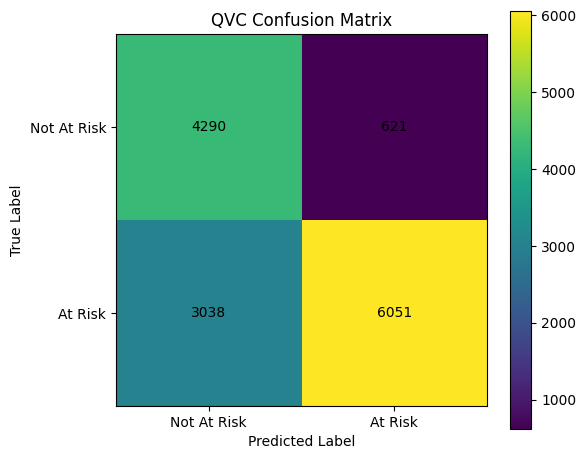

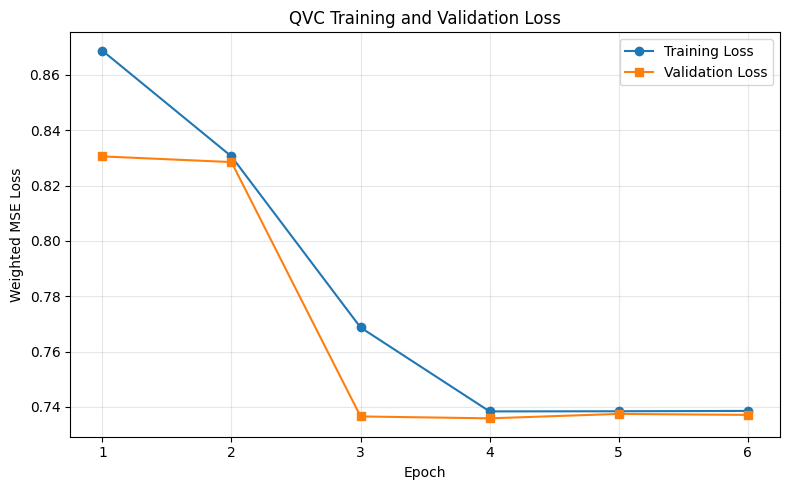

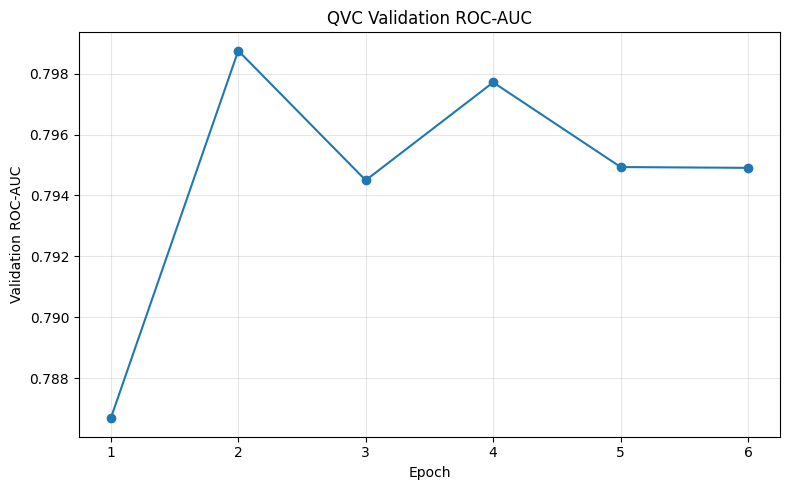

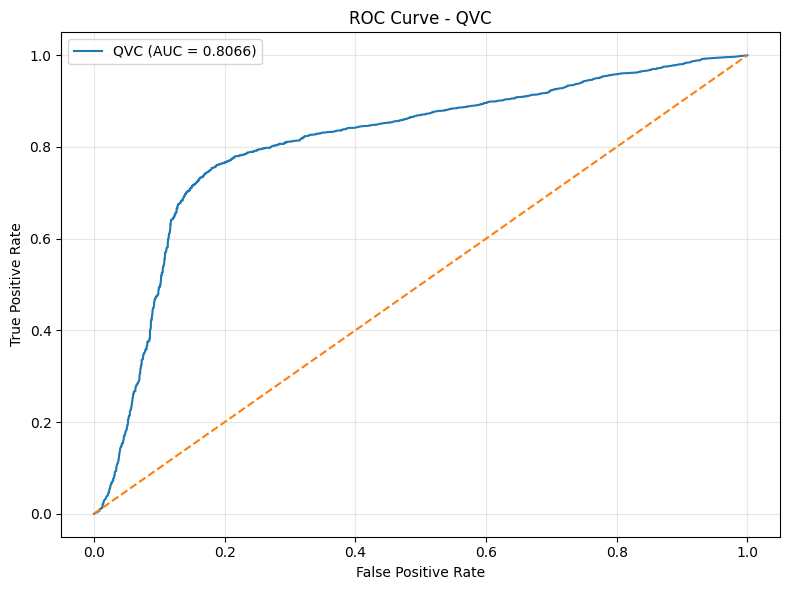

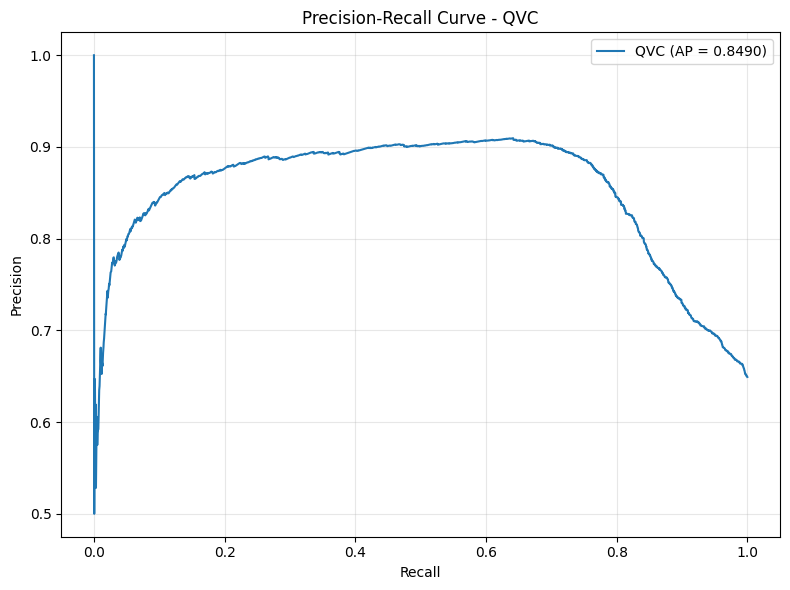

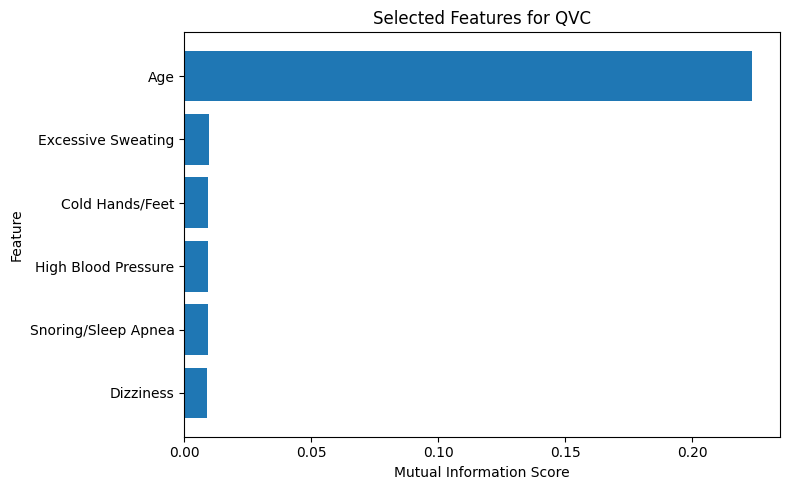

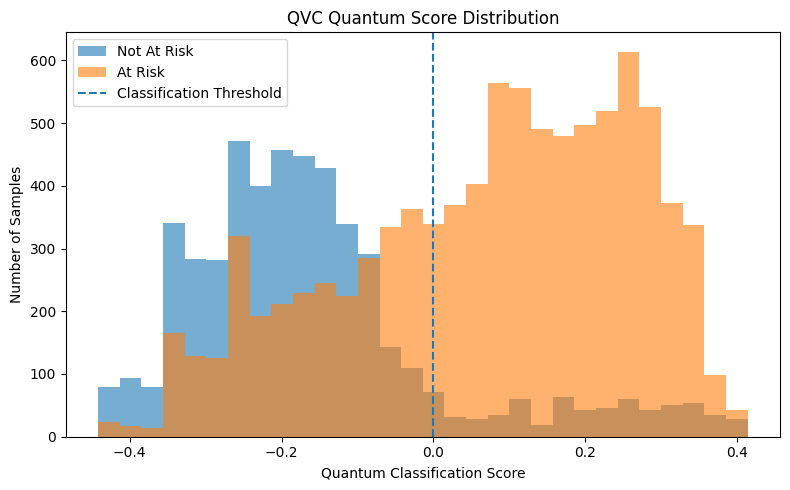


QVC RESULTS TABLE


,Model,Qubits,Quantum Layers,Trainable Parameters,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC,Average Precision,Training Time (s)
0,QVC,6,2,24,0.7386,0.9069,0.6657,0.8735,0.7678,0.8066,0.849,1994.5652



QVC EXPERIMENT COMPLETED

Model saved at:
/kaggle/working/qvc_stroke_model_cpu.pth

Results saved at:
/kaggle/working/qvc_stroke_results.csv

Quantum backend:
lightning.qubit

Execution:
CPU

Model architecture:
6-qubit pure variational quantum classifier

Classical hidden neural-network layers:
NONE



In [4]:
# ================================================================
# QUANTUM VARIATIONAL CLASSIFIER (QVC)
# STROKE RISK PREDICTION
# KAGGLE SINGLE-CELL
# CPU + PENNYLANE LIGHTNING.QUBIT
# ================================================================


# ================================================================
# 1. INSTALL PENNYLANE
# ================================================================

!pip install -q pennylane pennylane-lightning


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import random
import warnings
import copy
import time

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ================================================================
# 3. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ================================================================
# 4. EXECUTION DEVICE
# ================================================================

device = torch.device("cpu")


print("=" * 75)
print("QVC EXECUTION CONFIGURATION")
print("=" * 75)

print("PyTorch device      :", device)
print("Quantum backend     : lightning.qubit")
print("Execution           : CPU")
print("Model               : Quantum Variational Classifier")


# ================================================================
# 5. LOAD DATASET
# ================================================================

DATA_PATH = (
    "/kaggle/input/datasets/"
    "mahatiratusher/"
    "stroke-risk-prediction-dataset/"
    "stroke_risk_dataset.csv"
)


df = pd.read_csv(
    DATA_PATH
)


TARGET = "At Risk (Binary)"

LEAKAGE_FEATURE = "Stroke Risk (%)"


print(
    "\n" + "=" * 75
)

print(
    "DATASET INFORMATION"
)

print(
    "=" * 75
)


print(
    "Dataset shape:",
    df.shape
)


print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)


print(
    "\nMissing values:"
)

print(
    df.isnull().sum()
)


print(
    "\nTarget distribution:"
)

print(
    df[TARGET]
    .value_counts()
    .sort_index()
)


print(
    "\nTarget percentage:"
)

print(
    df[TARGET]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)


print(
    "\nExact duplicate rows:",
    df.duplicated().sum()
)


# ================================================================
# 6. VALIDATE REQUIRED COLUMNS
# ================================================================

required_columns = {
    TARGET,
    LEAKAGE_FEATURE,
    "Age"
}


missing_required = (
    required_columns
    .difference(df.columns)
)


if missing_required:

    raise ValueError(
        f"Required columns missing: "
        f"{missing_required}"
    )


# ================================================================
# 7. REMOVE TARGET LEAKAGE
# ================================================================

# Stroke Risk (%) is directly related to
# At Risk (Binary), so it MUST NOT be
# used as an input feature.


X = df.drop(

    columns=[
        TARGET,
        LEAKAGE_FEATURE
    ]

).copy()


y = (

    df[TARGET]
    .astype(int)
    .copy()
)


# ------------------------------------------------
# Validate target
# ------------------------------------------------

if not set(
    y.unique()
).issubset({0, 1}):

    raise ValueError(
        "Target must contain only 0 and 1."
    )


# ------------------------------------------------
# Validate features
# ------------------------------------------------

non_numeric_features = (

    X
    .select_dtypes(
        exclude=[np.number]
    )
    .columns
    .tolist()
)


if non_numeric_features:

    raise ValueError(
        f"Non-numeric features detected: "
        f"{non_numeric_features}"
    )


print(
    "\nNumber of usable input features:",
    X.shape[1]
)


print(
    "\nInput features:"
)


for feature in X.columns:

    print(
        "-",
        feature
    )


print(
    "\nRemoved leakage feature:",
    LEAKAGE_FEATURE
)


# ================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

# Final:
#
# Training   = 70%
# Validation = 10%
# Testing    = 20%


X_train_full, X_test, y_train_full, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=SEED,

        stratify=y
    )
)


X_train, X_val, y_train, y_val = (

    train_test_split(

        X_train_full,
        y_train_full,

        test_size=0.125,

        random_state=SEED,

        stratify=y_train_full
    )
)


print(
    "\n" + "=" * 75
)

print(
    "DATA SPLIT"
)

print(
    "=" * 75
)


print(
    "Training samples   :",
    len(X_train)
)

print(
    "Validation samples :",
    len(X_val)
)

print(
    "Testing samples    :",
    len(X_test)
)


print(

    "\nActual split:",

    f"{len(X_train)/len(df)*100:.1f}% Train |",

    f"{len(X_val)/len(df)*100:.1f}% Validation |",

    f"{len(X_test)/len(df)*100:.1f}% Test"
)


# ================================================================
# 9. MUTUAL INFORMATION FEATURE SELECTION
# ================================================================

# Age = continuous
#
# Remaining input variables = binary/discrete
#
# Feature selection is performed ONLY
# using the training data.


discrete_mask = np.array(

    [
        column != "Age"

        for column
        in X_train.columns
    ],

    dtype=bool
)


mi_scores = mutual_info_classif(

    X_train,

    y_train,

    discrete_features=discrete_mask,

    random_state=SEED
)


mi_df = pd.DataFrame({

    "Feature":
        X_train.columns,

    "MI_Score":
        mi_scores
})


mi_df = (

    mi_df

    .sort_values(

        by="MI_Score",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ================================================================
# 10. SELECT TOP 6 FEATURES
# ================================================================

# 6 features = 6 qubits


N_FEATURES = 6


selected_features = (

    mi_df

    .head(
        N_FEATURES
    )

    ["Feature"]

    .tolist()
)


print(
    "\n" + "=" * 75
)

print(
    "SELECTED FEATURES"
)

print(
    "=" * 75
)


for i, feature in enumerate(
    selected_features,
    1
):


    score = (

        mi_df.loc[

            mi_df["Feature"] == feature,

            "MI_Score"

        ].iloc[0]
    )


    print(

        f"{i}. "
        f"{feature} "
        f"| MI = {score:.6f}"
    )


# ================================================================
# 11. APPLY FEATURE SELECTION
# ================================================================

X_train_selected = (

    X_train[
        selected_features
    ]
    .copy()
)


X_val_selected = (

    X_val[
        selected_features
    ]
    .copy()
)


X_test_selected = (

    X_test[
        selected_features
    ]
    .copy()
)


# ================================================================
# 12. STANDARD SCALING
# ================================================================

# Fit ONLY on training data.


scaler = StandardScaler()


X_train_scaled = (

    scaler.fit_transform(
        X_train_selected
    )
)


X_val_scaled = (

    scaler.transform(
        X_val_selected
    )
)


X_test_scaled = (

    scaler.transform(
        X_test_selected
    )
)


# ================================================================
# 13. QUANTUM ANGLE ENCODING
# ================================================================

# Convert standardized features into
# approximately [-pi, +pi].


X_train_quantum = (

    np.pi

    *

    np.tanh(
        X_train_scaled
    )
)


X_val_quantum = (

    np.pi

    *

    np.tanh(
        X_val_scaled
    )
)


X_test_quantum = (

    np.pi

    *

    np.tanh(
        X_test_scaled
    )
)


# ================================================================
# 14. QVC TARGET ENCODING
# ================================================================

# Original labels:
#
# 0 = Not At Risk
# 1 = At Risk
#
# For a variational quantum classifier
# using Pauli-Z expectation values:
#
# 0 -> -1
# 1 -> +1
#
# Quantum output therefore naturally lives
# in the same [-1, +1] range.


y_train_qvc = (

    2.0
    *
    y_train.to_numpy()

    -
    1.0
)


y_val_qvc = (

    2.0
    *
    y_val.to_numpy()

    -
    1.0
)


y_test_qvc = (

    2.0
    *
    y_test.to_numpy()

    -
    1.0
)


# ================================================================
# 15. CONVERT TO TORCH TENSORS
# ================================================================

X_train_tensor = torch.tensor(

    X_train_quantum,

    dtype=torch.float32,

    device=device
)


X_val_tensor = torch.tensor(

    X_val_quantum,

    dtype=torch.float32,

    device=device
)


X_test_tensor = torch.tensor(

    X_test_quantum,

    dtype=torch.float32,

    device=device
)


y_train_tensor = torch.tensor(

    y_train_qvc,

    dtype=torch.float32,

    device=device
)


y_val_tensor = torch.tensor(

    y_val_qvc,

    dtype=torch.float32,

    device=device
)


y_test_tensor = torch.tensor(

    y_test_qvc,

    dtype=torch.float32,

    device=device
)


# ================================================================
# 16. DATASETS / DATALOADERS
# ================================================================

BATCH_SIZE = 32


loader_generator = (

    torch.Generator()

    .manual_seed(
        SEED
    )
)


train_dataset = TensorDataset(

    X_train_tensor,

    y_train_tensor
)


val_dataset = TensorDataset(

    X_val_tensor,

    y_val_tensor
)


test_dataset = TensorDataset(

    X_test_tensor,

    y_test_tensor
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    generator=loader_generator,

    pin_memory=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    pin_memory=False
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    pin_memory=False
)


# ================================================================
# 17. QUANTUM CONFIGURATION
# ================================================================

N_QUBITS = N_FEATURES

N_Q_LAYERS = 2


quantum_device = qml.device(

    "lightning.qubit",

    wires=N_QUBITS,

    shots=None
)


print(
    "\n" + "=" * 75
)

print(
    "QVC QUANTUM CONFIGURATION"
)

print(
    "=" * 75
)


print(
    "Quantum simulator      : lightning.qubit"
)

print(
    "Execution              : CPU"
)

print(
    "Number of qubits       :",
    N_QUBITS
)

print(
    "Variational layers     :",
    N_Q_LAYERS
)

print(
    "Differentiation        : adjoint"
)

print(
    "Classical hidden layer : NONE"
)


# ================================================================
# 18. QUANTUM CIRCUIT
# ================================================================

@qml.qnode(

    quantum_device,

    interface="torch",

    diff_method="adjoint"
)

def quantum_circuit(

    inputs,

    weights
):


    # ------------------------------------------------
    # DATA ENCODING
    # ------------------------------------------------

    for i in range(
        N_QUBITS
    ):


        qml.RY(

            inputs[i],

            wires=i
        )


    # ------------------------------------------------
    # VARIATIONAL QUANTUM LAYERS
    # ------------------------------------------------

    for layer in range(
        N_Q_LAYERS
    ):


        # --------------------------------------------
        # TRAINABLE ROTATIONS
        # --------------------------------------------

        for i in range(
            N_QUBITS
        ):


            qml.RY(

                weights[
                    layer,
                    i,
                    0
                ],

                wires=i
            )


            qml.RZ(

                weights[
                    layer,
                    i,
                    1
                ],

                wires=i
            )


        # --------------------------------------------
        # RING ENTANGLEMENT
        # --------------------------------------------

        for i in range(
            N_QUBITS - 1
        ):


            qml.CNOT(

                wires=[
                    i,
                    i + 1
                ]
            )


        qml.CNOT(

            wires=[
                N_QUBITS - 1,
                0
            ]
        )


    # ------------------------------------------------
    # MEASURE ALL SIX QUBITS
    # ------------------------------------------------

    return tuple(

        qml.expval(
            qml.PauliZ(i)
        )

        for i in range(
            N_QUBITS
        )
    )


# ================================================================
# 19. QVC MODEL
# ================================================================

class QuantumVariationalClassifier(
    nn.Module
):


    def __init__(
        self,
        n_qubits,
        n_layers
    ):


        super().__init__()


        self.n_qubits = (
            n_qubits
        )


        self.n_layers = (
            n_layers
        )


        # ------------------------------------------------
        # TRAINABLE QUANTUM PARAMETERS
        # ------------------------------------------------

        self.q_weights = nn.Parameter(

            0.01

            *

            torch.randn(

                n_layers,

                n_qubits,

                2,

                dtype=torch.float32
            )
        )


    # ----------------------------------------------------
    # FORWARD
    # ----------------------------------------------------

    def forward(
        self,
        x
    ):


        scores = []


        for sample in x:


            q_result = quantum_circuit(

                sample,

                self.q_weights
            )


            q_result = torch.stack(

                list(
                    q_result
                )
            )


            q_result = q_result.to(
                dtype=torch.float32
            )


            # --------------------------------------------
            # PURE QVC OUTPUT
            # --------------------------------------------
            #
            # No classical neural network.
            #
            # Average the six Pauli-Z expectation values.
            #
            # Output remains in approximately:
            #
            # [-1, +1]
            #
            # -1 -> Not At Risk
            # +1 -> At Risk


            score = torch.mean(
                q_result
            )


            scores.append(
                score
            )


        return torch.stack(
            scores
        )


# ================================================================
# 20. INITIALIZE QVC
# ================================================================

model = QuantumVariationalClassifier(

    n_qubits=N_QUBITS,

    n_layers=N_Q_LAYERS

).to(
    device
)


print(
    "\n" + "=" * 75
)

print(
    "QUANTUM VARIATIONAL CLASSIFIER"
)

print(
    "=" * 75
)


print(
    model
)


# ================================================================
# 21. NUMBER OF TRAINABLE PARAMETERS
# ================================================================

trainable_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print(
    "\nTrainable parameters:",
    trainable_parameters
)


# ================================================================
# 22. CLASS WEIGHTS
# ================================================================

# Balanced sample weighting.
#
# This accounts for the unequal number
# of class 0 and class 1 examples.


class_counts = np.bincount(

    y_train.to_numpy(),

    minlength=2
)


negative_count = int(
    class_counts[0]
)


positive_count = int(
    class_counts[1]
)


total_count = (

    negative_count
    +
    positive_count
)


class0_weight = (

    total_count

    /

    (
        2.0
        *
        negative_count
    )
)


class1_weight = (

    total_count

    /

    (
        2.0
        *
        positive_count
    )
)


print(
    "\nClass 0 samples:",
    negative_count
)


print(
    "Class 1 samples:",
    positive_count
)


print(
    "Class 0 weight:",
    round(
        class0_weight,
        6
    )
)


print(
    "Class 1 weight:",
    round(
        class1_weight,
        6
    )
)


# ================================================================
# 23. WEIGHTED QVC LOSS
# ================================================================

# QVC prediction:
#
# -1 ... +1
#
# Target:
#
# -1 or +1
#
# Therefore weighted Mean Squared Error
# is a natural loss for this QVC.


def weighted_qvc_loss(

    predictions,

    targets
):


    sample_weights = torch.where(

        targets > 0,

        torch.tensor(
            class1_weight,
            dtype=torch.float32,
            device=device
        ),

        torch.tensor(
            class0_weight,
            dtype=torch.float32,
            device=device
        )
    )


    squared_error = (

        predictions

        -

        targets

    ) ** 2


    loss = torch.mean(

        sample_weights
        *
        squared_error
    )


    return loss


# ================================================================
# 24. OPTIMIZER
# ================================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.01,

    weight_decay=1e-4
)


# ================================================================
# 25. LEARNING RATE SCHEDULER
# ================================================================

scheduler = (

    torch.optim

    .lr_scheduler

    .ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=2
    )
)


# ================================================================
# 26. TRAIN ONE EPOCH
# ================================================================

def train_one_epoch(

    model,

    loader,

    optimizer
):


    model.train()


    running_loss = 0.0


    for (
        X_batch,
        y_batch
    ) in loader:


        optimizer.zero_grad(
            set_to_none=True
        )


        # --------------------------------------------
        # FORWARD
        # --------------------------------------------

        scores = model(
            X_batch
        )


        # --------------------------------------------
        # LOSS
        # --------------------------------------------

        loss = weighted_qvc_loss(

            scores,

            y_batch
        )


        # --------------------------------------------
        # BACKPROPAGATION
        # --------------------------------------------

        loss.backward()


        # --------------------------------------------
        # OPTIMIZATION
        # --------------------------------------------

        optimizer.step()


        running_loss += (

            loss.item()

            *

            X_batch.size(0)
        )


    epoch_loss = (

        running_loss

        /

        len(
            loader.dataset
        )
    )


    return epoch_loss


# ================================================================
# 27. EVALUATION FUNCTION
# ================================================================

@torch.no_grad()

def evaluate(

    model,

    loader
):


    model.eval()


    running_loss = 0.0


    all_scores = []

    all_targets_pm1 = []


    for (
        X_batch,
        y_batch
    ) in loader:


        scores = model(
            X_batch
        )


        loss = weighted_qvc_loss(

            scores,

            y_batch
        )


        running_loss += (

            loss.item()

            *

            X_batch.size(0)
        )


        all_scores.extend(

            scores

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


        all_targets_pm1.extend(

            y_batch

            .detach()

            .cpu()

            .numpy()

            .tolist()
        )


    average_loss = (

        running_loss

        /

        len(
            loader.dataset
        )
    )


    all_scores = np.asarray(

        all_scores,

        dtype=np.float64
    )


    all_targets_pm1 = np.asarray(

        all_targets_pm1,

        dtype=np.float64
    )


    # ------------------------------------------------
    # Convert target:
    #
    # -1 -> 0
    # +1 -> 1
    # ------------------------------------------------

    all_targets = (

        all_targets_pm1
        >
        0

    ).astype(
        np.int64
    )


    # ------------------------------------------------
    # Classification threshold
    #
    # score >= 0 -> class 1
    # score <  0 -> class 0
    # ------------------------------------------------

    predictions = (

        all_scores
        >=
        0.0

    ).astype(
        np.int64
    )


    # ------------------------------------------------
    # Convert quantum score [-1,+1]
    # to probability-like score [0,1]
    # ------------------------------------------------

    probabilities = (

        all_scores
        +
        1.0

    ) / 2.0


    probabilities = np.clip(

        probabilities,

        0.0,

        1.0
    )


    return (

        average_loss,

        all_targets,

        predictions,

        probabilities,

        all_scores
    )


# ================================================================
# 28. TRAINING CONFIGURATION
# ================================================================

EPOCHS = 10


EARLY_STOPPING_PATIENCE = 4


train_losses = []

val_losses = []

val_auc_history = []


best_val_auc = (
    -np.inf
)


best_state = None


best_epoch = 0


epochs_without_improvement = 0


# ================================================================
# 29. START QVC TRAINING
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "STARTING QVC TRAINING"
)

print(
    "=" * 75
)


training_start = (
    time.time()
)


for epoch in range(
    EPOCHS
):


    epoch_start = (
        time.time()
    )


    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer
    )


    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    (
        val_loss,

        y_val_true,

        y_val_pred,

        y_val_prob,

        y_val_score

    ) = evaluate(

        model,

        val_loader
    )


    # ------------------------------------------------
    # VALIDATION ROC-AUC
    # ------------------------------------------------

    val_auc = roc_auc_score(

        y_val_true,

        y_val_prob
    )


    # ------------------------------------------------
    # STORE HISTORY
    # ------------------------------------------------

    train_losses.append(
        train_loss
    )


    val_losses.append(
        val_loss
    )


    val_auc_history.append(
        val_auc
    )


    # ------------------------------------------------
    # SCHEDULER
    # ------------------------------------------------

    scheduler.step(
        val_loss
    )


    # ------------------------------------------------
    # SAVE BEST MODEL USING VALIDATION ROC-AUC
    # ------------------------------------------------

    if (

        val_auc

        >

        best_val_auc + 1e-8
    ):


        best_val_auc = (
            val_auc
        )


        best_epoch = (
            epoch + 1
        )


        epochs_without_improvement = 0


        best_state = copy.deepcopy(

            model.state_dict()
        )


    else:


        epochs_without_improvement += 1


    current_lr = (

        optimizer
        .param_groups[0]
        ["lr"]
    )


    epoch_time = (

        time.time()

        -

        epoch_start
    )


    print(

        f"Epoch "
        f"[{epoch + 1}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val AUC: "
        f"{val_auc:.4f} | "

        f"LR: "
        f"{current_lr:.6f} | "

        f"Time: "
        f"{epoch_time:.2f}s"
    )


    # ------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------

    if (

        epochs_without_improvement

        >=

        EARLY_STOPPING_PATIENCE
    ):


        print(

            f"\nEarly stopping "
            f"at epoch "
            f"{epoch + 1}."
        )


        break


total_training_time = (

    time.time()

    -

    training_start
)


# ================================================================
# 30. LOAD BEST QVC MODEL
# ================================================================

if best_state is None:

    raise RuntimeError(
        "No valid QVC checkpoint was created."
    )


model.load_state_dict(
    best_state
)


print(
    "\nBest validation QVC model loaded."
)


print(
    "Best epoch:",
    best_epoch
)


print(
    "Best validation ROC-AUC:",
    round(
        best_val_auc,
        4
    )
)


# ================================================================
# 31. FINAL TEST EVALUATION
# ================================================================

(
    test_loss,

    y_true,

    y_pred,

    y_prob,

    y_score

) = evaluate(

    model,

    test_loader
)


# ================================================================
# 32. CALCULATE METRICS
# ================================================================

accuracy = accuracy_score(

    y_true,

    y_pred
)


precision = precision_score(

    y_true,

    y_pred,

    zero_division=0
)


recall = recall_score(

    y_true,

    y_pred,

    zero_division=0
)


f1 = f1_score(

    y_true,

    y_pred,

    zero_division=0
)


roc_auc = roc_auc_score(

    y_true,

    y_prob
)


average_precision = (
    average_precision_score(

        y_true,

        y_prob
    )
)


# ================================================================
# 33. CONFUSION MATRIX + SPECIFICITY
# ================================================================

cm = confusion_matrix(

    y_true,

    y_pred,

    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


specificity = (

    tn

    /

    (tn + fp)

    if (
        tn + fp
    ) > 0

    else 0.0
)


# ================================================================
# 34. PRINT FINAL TEST RESULTS
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "FINAL QVC TEST RESULTS"
)

print(
    "=" * 75
)


print(
    f"Test Loss          : "
    f"{test_loss:.4f}"
)


print(
    f"Accuracy           : "
    f"{accuracy:.4f}"
)


print(
    f"Precision          : "
    f"{precision:.4f}"
)


print(
    f"Recall/Sensitivity : "
    f"{recall:.4f}"
)


print(
    f"Specificity        : "
    f"{specificity:.4f}"
)


print(
    f"F1 Score           : "
    f"{f1:.4f}"
)


print(
    f"ROC-AUC            : "
    f"{roc_auc:.4f}"
)


print(
    f"Average Precision  : "
    f"{average_precision:.4f}"
)


print(
    f"Trainable Params   : "
    f"{trainable_parameters}"
)


print(
    f"Training Time      : "
    f"{total_training_time:.2f} seconds"
)


print(
    "=" * 75
)


# ================================================================
# 35. CLASSIFICATION REPORT
# ================================================================

print(
    "\nClassification Report:\n"
)


print(

    classification_report(

        y_true,

        y_pred,

        labels=[0, 1],

        target_names=[

            "Not At Risk",

            "At Risk"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 36. CONFUSION MATRIX PLOT
# ================================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm
)


plt.title(
    "QVC Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.xticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


plt.yticks(

    [0, 1],

    [
        "Not At Risk",
        "At Risk"
    ]
)


for i in range(2):

    for j in range(2):


        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ================================================================
# 37. TRAINING / VALIDATION LOSS CURVE
# ================================================================

epoch_axis = range(

    1,

    len(
        train_losses
    ) + 1
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epoch_axis,

    train_losses,

    marker="o",

    label="Training Loss"
)


plt.plot(

    epoch_axis,

    val_losses,

    marker="s",

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Weighted MSE Loss"
)


plt.title(
    "QVC Training and Validation Loss"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ================================================================
# 38. VALIDATION ROC-AUC HISTORY
# ================================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    epoch_axis,

    val_auc_history,

    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation ROC-AUC"
)


plt.title(
    "QVC Validation ROC-AUC"
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ================================================================
# 39. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(

    y_true,

    y_prob
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    fpr,

    tpr,

    label=(

        f"QVC "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - QVC"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ================================================================
# 40. PRECISION-RECALL CURVE
# ================================================================

(
    precision_curve,

    recall_curve,

    _
) = precision_recall_curve(

    y_true,

    y_prob
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=(

        f"QVC "
        f"(AP = {average_precision:.4f})"
    )
)


plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve - QVC"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ================================================================
# 41. MUTUAL INFORMATION FEATURE PLOT
# ================================================================

top_features = mi_df.head(
    N_FEATURES
)


plt.figure(
    figsize=(8, 5)
)


plt.barh(

    top_features[
        "Feature"
    ][::-1],

    top_features[
        "MI_Score"
    ][::-1]
)


plt.xlabel(
    "Mutual Information Score"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Selected Features for QVC"
)


plt.tight_layout()

plt.show()


# ================================================================
# 42. QVC SCORE DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(

    y_score[
        y_true == 0
    ],

    bins=30,

    alpha=0.6,

    label="Not At Risk"
)


plt.hist(

    y_score[
        y_true == 1
    ],

    bins=30,

    alpha=0.6,

    label="At Risk"
)


plt.axvline(

    0.0,

    linestyle="--",

    label="Classification Threshold"
)


plt.xlabel(
    "Quantum Classification Score"
)


plt.ylabel(
    "Number of Samples"
)


plt.title(
    "QVC Quantum Score Distribution"
)


plt.legend()


plt.tight_layout()

plt.show()


# ================================================================
# 43. RESULTS TABLE
# ================================================================

results = pd.DataFrame({


    "Model": [

        "QVC"
    ],


    "Qubits": [

        N_QUBITS
    ],


    "Quantum Layers": [

        N_Q_LAYERS
    ],


    "Trainable Parameters": [

        trainable_parameters
    ],


    "Accuracy": [

        accuracy
    ],


    "Precision": [

        precision
    ],


    "Recall/Sensitivity": [

        recall
    ],


    "Specificity": [

        specificity
    ],


    "F1-Score": [

        f1
    ],


    "ROC-AUC": [

        roc_auc
    ],


    "Average Precision": [

        average_precision
    ],


    "Training Time (s)": [

        total_training_time
    ]

})


print(
    "\n" + "=" * 75
)

print(
    "QVC RESULTS TABLE"
)

print(
    "=" * 75
)


display(
    results.round(4)
)


# ================================================================
# 44. SAVE MODEL
# ================================================================

MODEL_PATH = (

    "/kaggle/working/"
    "qvc_stroke_model_cpu.pth"
)


RESULTS_PATH = (

    "/kaggle/working/"
    "qvc_stroke_results.csv"
)


checkpoint = {


    "model_state_dict":
        model.state_dict(),


    "selected_features":
        selected_features,


    "mi_scores":

        dict(

            zip(

                mi_df["Feature"],

                mi_df["MI_Score"]
            )
        ),


    "scaler_mean":
        scaler.mean_,


    "scaler_scale":
        scaler.scale_,


    "n_qubits":
        N_QUBITS,


    "n_layers":
        N_Q_LAYERS,


    "batch_size":
        BATCH_SIZE,


    "seed":
        SEED,


    "best_epoch":
        best_epoch,


    "best_validation_auc":
        best_val_auc,


    "class0_weight":
        class0_weight,


    "class1_weight":
        class1_weight,


    "trainable_parameters":
        trainable_parameters,


    "test_accuracy":
        accuracy,


    "test_precision":
        precision,


    "test_recall":
        recall,


    "test_specificity":
        specificity,


    "test_f1":
        f1,


    "test_roc_auc":
        roc_auc,


    "test_average_precision":
        average_precision,


    "training_time_seconds":
        total_training_time,


    "quantum_backend":
        "lightning.qubit",


    "execution_device":
        "CPU",


    "differentiation":
        "adjoint",


    "loss":
        "Weighted MSE",


    "classification_threshold":
        0.0
}


torch.save(

    checkpoint,

    MODEL_PATH
)


results.to_csv(

    RESULTS_PATH,

    index=False
)


# ================================================================
# 45. FINAL MESSAGE
# ================================================================

print(
    "\n" + "=" * 75
)

print(
    "QVC EXPERIMENT COMPLETED"
)

print(
    "=" * 75
)


print(
    "\nModel saved at:"
)

print(
    MODEL_PATH
)


print(
    "\nResults saved at:"
)

print(
    RESULTS_PATH
)


print(
    "\nQuantum backend:"
)

print(
    "lightning.qubit"
)


print(
    "\nExecution:"
)

print(
    "CPU"
)


print(
    "\nModel architecture:"
)

print(
    "6-qubit pure variational quantum classifier"
)


print(
    "\nClassical hidden neural-network layers:"
)

print(
    "NONE"
)


print(
    "\n" + "=" * 75
)